In [ ]:
# ovito
from ovito.io import import_file
from ovito.data import CutoffNeighborFinder

# data analysis
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter
import pyarrow as pa

# parsing
import glob, os, re, json

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.ticker import FixedLocator, ScalarFormatter
import matplotlib as mpl
import cmocean

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "mathtext.fontset": "cm",        
    "font.size": 12                  
})

mpl.rcParams["text.usetex"] = True  # full LaTeX
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"  # optional

In [2]:
output_directory = '/Users/arlenlex/Library/CloudStorage/OneDrive-Stanford/Stanford_Research/2026 Spring/final_paper_figures/'

# Contact Law and Bond Model Figure

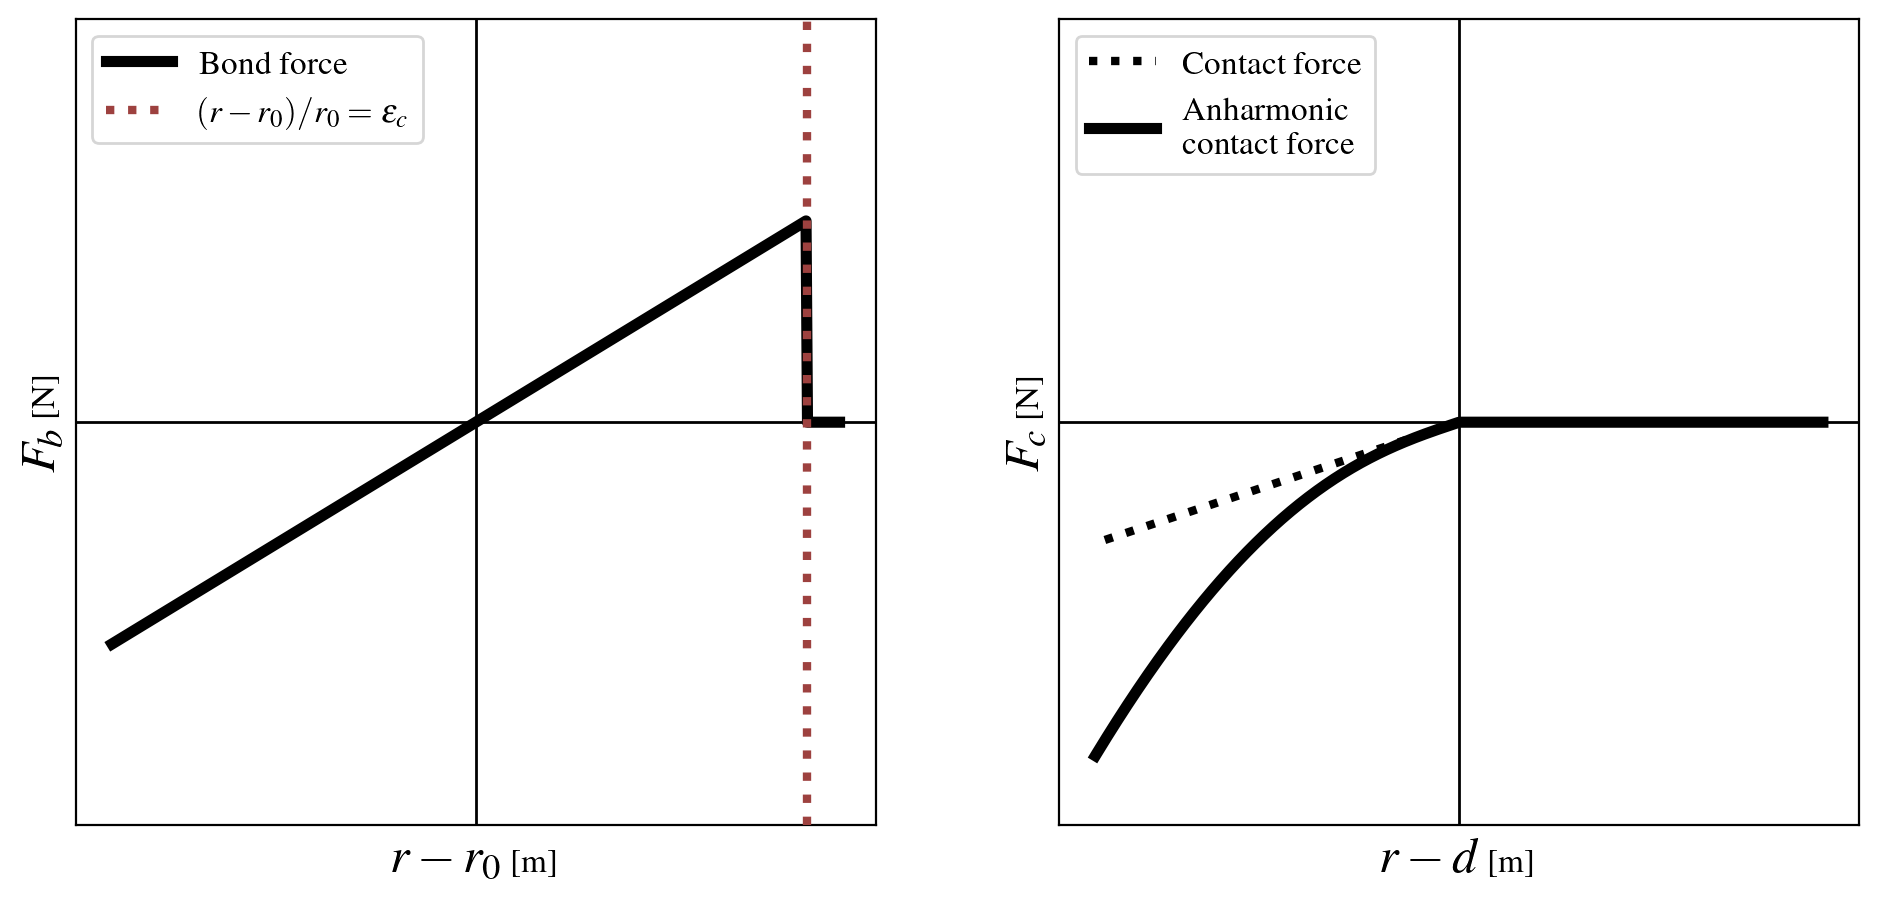

In [3]:
# parameters 
kn    = 1e9
kc    = 1e5
r0    = 1000.0
ecrit = 1e-4

# bond force 
r_bond    = np.linspace(999.89, 1000.11, 500)
strain_b  = (r_bond - r0) / r0

F_bond_linear = kn * (r_bond - r0)

# set to zero for bond broken
F_bond_plot = np.zeros_like(F_bond_linear)
mask_bond   = strain_b < ecrit
F_bond_plot[mask_bond] = F_bond_linear[mask_bond]

# contact force 
r_contact   = np.linspace(400, 1600, 500)
strain_c    = (r_contact - r0) / r0
ka          = 50 * kc / (2 * r_contact)**2

F_contact       = kc * (r_contact - r0)
F_contact_anh   = F_contact + ka * (r_contact - r0)**3

F_contact_plot     = np.zeros_like(F_contact)
F_contact_anh_plot = np.zeros_like(F_contact_anh)

mask_contact = strain_c >= ecrit
F_contact_plot[mask_contact]     = F_contact[mask_contact]
F_contact_anh_plot[mask_contact] = F_contact_anh[mask_contact]


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax0, ax1 = axes
fig.tight_layout(pad=2.0, w_pad=3.0)

# bond force plot 
ax0.plot(strain_b, F_bond_plot, lw=4, ls='-', color='k', label='Bond force')
ax0.axvline(ecrit, color="#9d413f", lw=3, ls=':', 
            label=r'$(r-r_0)/r_0 = \epsilon_c$', zorder = 12)
ax0.axvline(0, color='k', lw=1)
ax0.axhline(0, color='k', lw=1)

ax0.set_ylabel(r'$F_b \large {\text{  [N]}}$', fontsize=18)
ax0.set_xlabel(r'$r-r_0 \large {\text{   [m]}}$', fontsize=18)
ax0.set_yticks(np.linspace(-2e8, 2e8, 5))
ax0.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
ax0.set_ylim(-2e8, 2e8)
ax0.legend(loc='upper left')

# contact force plot 
ax1.plot(-strain_c, -F_contact_plot,     lw=3, ls=':', color='k', 
         label='Contact force')
ax1.plot(-strain_c, -F_contact_anh_plot, lw=4, ls='-',  color='k', 
         label='Anharmonic\ncontact force')
ax1.axvline(0, color='k', lw=1)
ax1.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$F_c \large {\text{  [N]}}$", fontsize=18)
ax1.set_xlabel(r'$r-d \large {\text{   [m]}}$', fontsize=18)
ax1.set_yticks(np.linspace(-2e8, 2e8, 5))
ax1.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
ax1.legend(loc='upper left')

plt.savefig(os.path.join(output_directory, 'bond_contact_no_balls.png'), dpi=300,bbox_inches='tight')
plt.show()

# Narrow Channel Schematic

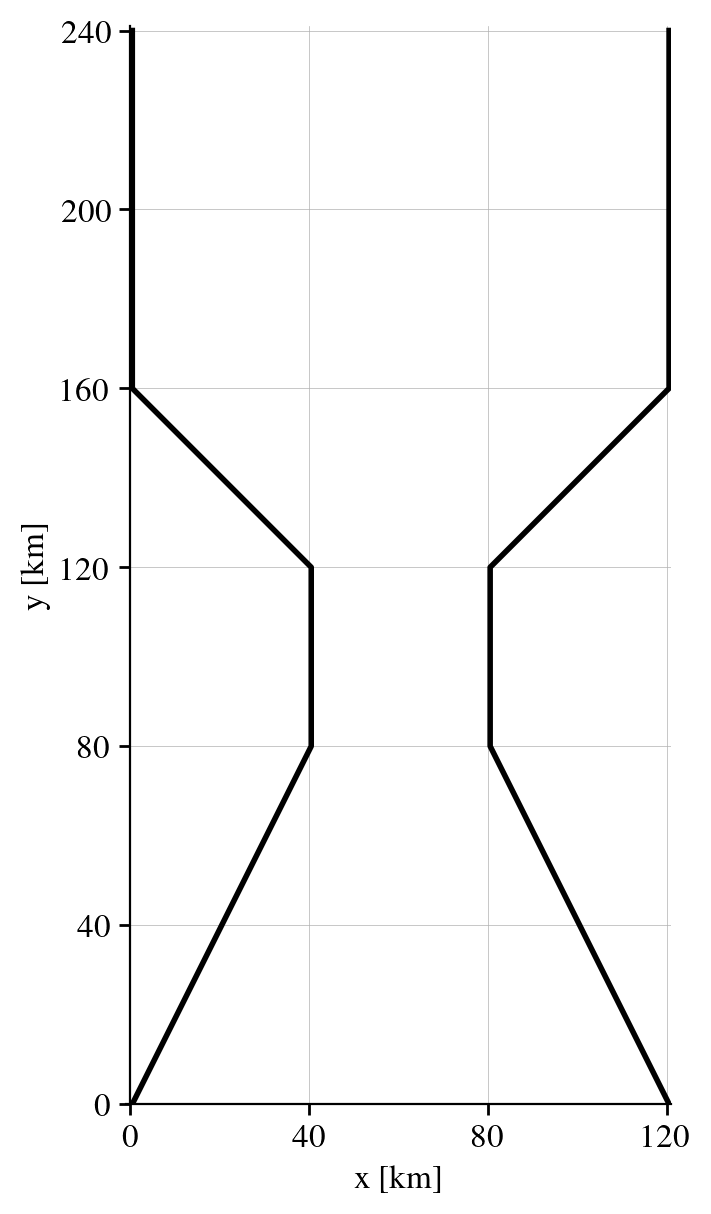

In [4]:
# --- geometry (km) ---
W_top = 120.0     # top width
W_choke = 40.0   # narrow width
H_top_vert = 80.0
H_converge = 40.0
H_choke_vert = 40.0
H_diverge = 80.0

x_top = W_top / 2
x_thr = W_choke / 2

y0 = 0.0
y1 = y0 + H_top_vert
y2 = y1 + H_converge
y3 = y2 + H_choke_vert
y4 = y3 + H_diverge  # 240

# Left and right wall lines 
left = np.array([
    [-x_top, y0],
    [-x_top, y1],
    [-x_thr, y2],
    [-x_thr, y3],
    [-x_top, y4],
])

right = np.array([
    [ x_top, y0],
    [ x_top, y1],
    [ x_thr, y2],
    [ x_thr, y3],
    [ x_top, y4],
])

# ------------------------------------------------------------
# Put origin (0,0) at the bottom-left corner of the geometry:
# bottom-left is (-x_top, y0)
# ------------------------------------------------------------
origin_x = -x_top-0.5
origin_y = y0

left_plot  = left.copy()
right_plot = right.copy()
left_plot[:, 0]  = left[:, 0]  - origin_x
right_plot[:, 0] = right[:, 0] - origin_x
left_plot[:, 1]  = left[:, 1]  - origin_y
right_plot[:, 1] = right[:, 1] - origin_y

left_plot[:, 1]  = y4 - left_plot[:, 1]
right_plot[:, 1] = y4 - right_plot[:, 1]

# --- plot ---
fig, ax = plt.subplots(figsize=(5, 7))

ax.plot(left_plot[:, 0],  left_plot[:, 1],  lw=2, color='k')
ax.plot(right_plot[:, 0], right_plot[:, 1], lw=2, color='k')

ax.set_aspect("equal", adjustable="box")

# Limits 
xmax_tick = 120
ymax_tick = 240
x_extra = 1
y_extra = 1
ax.set_xlim(0 - x_extra, xmax_tick + x_extra)
ax.set_ylim(0 - y_extra, ymax_tick + y_extra)

# Only left + bottom spines for the axes
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_position(("data", 0))     # y-axis at x=0
ax.spines["bottom"].set_position(("data", 0))   # x-axis at y=0

# Ticks every 40 km
ax.xaxis.set_major_locator(FixedLocator([0, 40, 80, 120]))
ax.yaxis.set_major_locator(FixedLocator([0, 40, 80, 120, 160, 200, 240]))
ax.tick_params(axis="both", direction="out", length=4, width=1, pad=3)

# Labels
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_xlim(-1,121)
ax.set_ylim(0,241)

plt.grid(lw=0.25)
plt.savefig(os.path.join(output_directory, 'geometry.png'), dpi=300, bbox_inches='tight')

plt.show()


# Size Effect

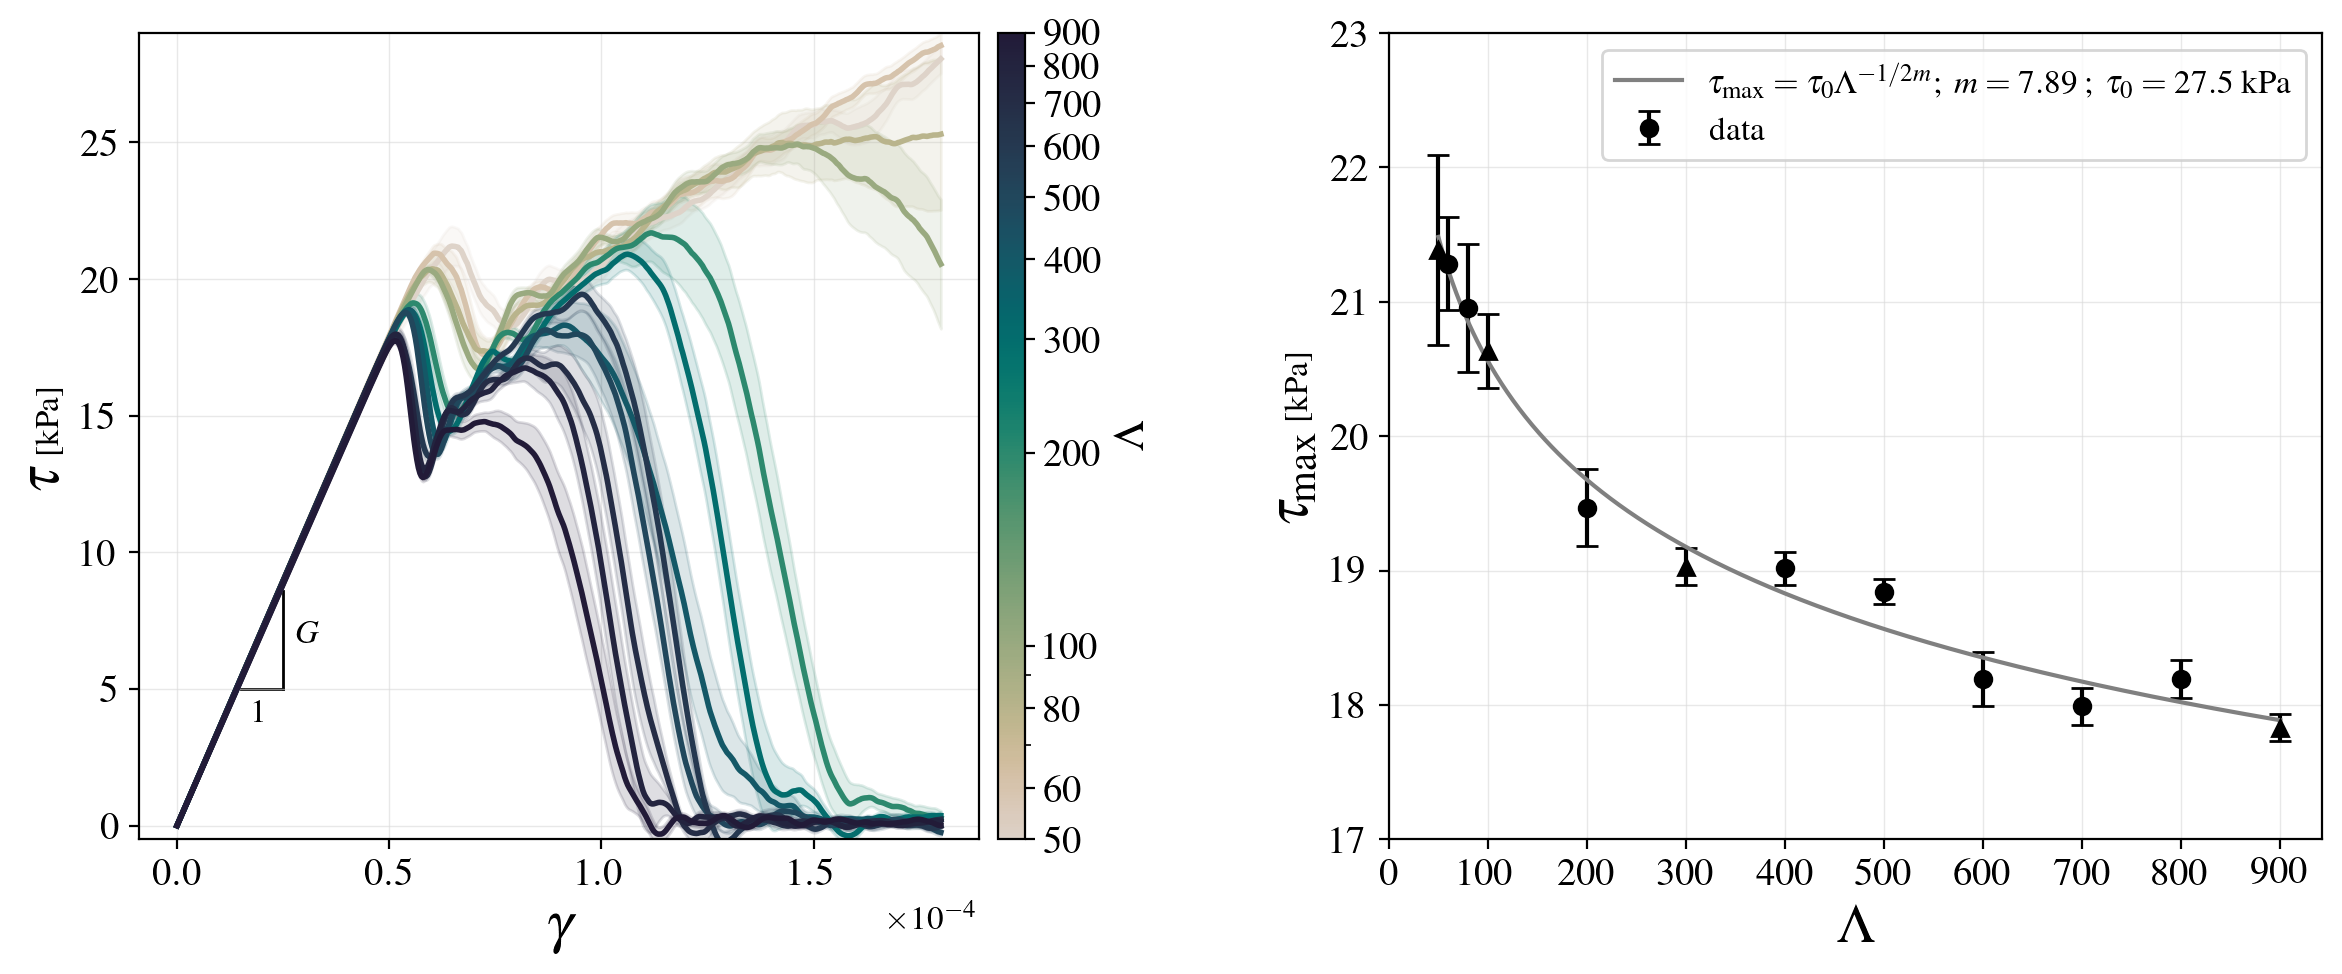

In [5]:
# helper functions

def first_peak_before_drop_idx(stress_array, strain_array):
    """
    Detects index of the time of failure by detecting the first time the stress
    that is lower than the previous value. 

    If there is no drop, return the global max stress and its strain.
    """
    s = np.asarray(stress_array)
    e = np.asarray(strain_array)

    if s.size == 0:
        return np.nan, np.nan, np.nan
    if s.size == 1:
        return 0, s[0], e[0]

    diffs = np.diff(s)
    drop_idxs = np.where(diffs < 0)[0]

    if drop_idxs.size == 0:
        idx = int(np.argmax(s))
        print("material didn't fail.")
        return idx, s[idx], e[idx]

    idx = int(drop_idxs[0])
    return idx, s[idx], e[idx]


def weibull_fit(x, y):
    """
    For fitting the Weibull curve to the max strength data. 

    Fit y = A * x^alpha :
        log y = log A + alpha log x + eps

    Returns:
        A_hat, m_hat (where alpha=1/m), alpha_hat,
        R2_log, mult_rmse_factor, mape_percent
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        raise ValueError("Need at least 3 positive (x,y) points.")

    lx = np.log(x)
    ly = np.log(y)

    # OLS in log space
    alpha_hat, logA_hat = np.polyfit(lx, ly, 1)
    A_hat = float(np.exp(logA_hat))

    # derived parameter
    m_hat = float(1.0 / alpha_hat)

    # predictions
    ly_hat = logA_hat + alpha_hat * lx
    y_hat = A_hat * x**alpha_hat

    # GOF: R^2 in log space
    ss_res = float(np.sum((ly - ly_hat)**2))
    ss_tot = float(np.sum((ly - np.mean(ly))**2))
    R2_log = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    # GOF: multiplicative RMSE factor (typical factor error)
    rmse_log = float(np.sqrt(np.mean((ly - ly_hat)**2)))
    mult_rmse_factor = float(np.exp(rmse_log))

    # GOF: MAPE in linear space (percent)
    mape_percent = float(100.0 * np.mean(np.abs((y - y_hat) / y)))

    return A_hat, m_hat, float(alpha_hat), R2_log, mult_rmse_factor, mape_percent


# ---------- path to dataframe ----------
df_path = "data/macroscopic_shear_stress.parquet"

# ---------- read dataframe ----------
df = pd.read_parquet(df_path)

# ensure sorted axes
strain = np.sort(df["strain"].unique())
size_ratio = 1.0 / np.sort(df["granularity"].unique())
seeds = np.sort(df["seed"].unique())

order = np.argsort(size_ratio)

# ---------- colormap (crop off the last 10%) ----------
base_cmap = cmocean.cm.rain
cmap = mpl.colors.ListedColormap(base_cmap(np.linspace(0.1, 1, 256)))

# ---------- color normalization ----------
norm = mpl.colors.LogNorm(
    vmin=size_ratio.min(),
    vmax=size_ratio.max()
)

# ---------- plotting ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(pad=2.0, w_pad=7.0)

peak_means = []
peak_stderrs = []
lam_arr = []

for j, idx in enumerate(order):
    lam = float(size_ratio[idx])

    sub = (
        df[np.isclose(df["granularity"], 1.0 / lam)]
        .pivot(index="strain", columns="seed", values="stress")
        .reindex(strain)
    )

    macros = sub.to_numpy().T
    n_seeds = macros.shape[0]

    mean_macro = np.nanmean(macros, axis=0)

    if n_seeds > 1:
        stderr_macro = np.nanstd(macros, axis=0, ddof=1) / np.sqrt(n_seeds)
    else:
        stderr_macro = np.zeros_like(mean_macro)

    # ---- color from Lambda ----
    c = cmap(norm(lam))

    # ---- left panel ----
    ax1.plot(strain, mean_macro / 1e3, color=c, lw=2)
    ax1.fill_between(
        strain,
        (mean_macro - stderr_macro) / 1e3,
        (mean_macro + stderr_macro) / 1e3,
        color=c, alpha=0.15
    )

    # ---- per-seed peaks ----
    peak_stresses = []
    for mcurve in macros:
        _, p_stress, _ = first_peak_before_drop_idx(mcurve, strain)
        peak_stresses.append(p_stress)

    peak_stresses = np.asarray(peak_stresses, dtype=float)
    peak_mean = float(np.nanmean(peak_stresses))

    if n_seeds > 1:
        peak_stderr = float(np.nanstd(peak_stresses, ddof=1) / np.sqrt(n_seeds))
    else:
        peak_stderr = 0.0

    peak_means.append(peak_mean)
    peak_stderrs.append(peak_stderr)
    lam_arr.append(lam)

# ---------- arrays ----------
lam_arr = np.asarray(lam_arr, dtype=float)
peak_means = np.asarray(peak_means, dtype=float)
peak_stderrs = np.asarray(peak_stderrs, dtype=float)

# ---------------- Power-law fit via OLS in log-log space ----------------
mask = (lam_arr > 0) & (peak_means > 0) & np.isfinite(lam_arr) & np.isfinite(peak_means)
lam_fit_data = lam_arr[mask]
sigma_fit_data = peak_means[mask]

A_hat, m_hat, alpha_hat, R2_log, mult_rmse_fac, mape_pct = weibull_fit(
    lam_fit_data, sigma_fit_data
)

lam_smooth = np.logspace(np.log10(lam_arr.min()), np.log10(lam_arr.max()), 300)
sigma_smooth = A_hat * lam_smooth**alpha_hat

# ---------- left panel formatting ----------
ax1.set_xlabel(r"$\gamma$", size='x-large')
ax1.set_ylabel(r"$\tau \large {\text{  [kPa]}}$", size='x-large')
ax1.set_ylim(-0.5, 29)
ax1.set_xlabel(r"$\gamma$", fontsize=20)
ax1.set_ylabel(r"$\tau \large {\text{  [kPa]}}$", fontsize=20)
ax1.tick_params(axis='both', labelsize=14)

ax1.ticklabel_format(axis='x', style='sci', scilimits=(-2, 2))
ax1.grid(which="major", linestyle="-", linewidth=0.5, color="0.85", alpha=0.6)
ax1.set_axisbelow(True)

# shear modulus annotation
x0 = 1.5e-5
x1_ = 2.5e-5
y0 = 5
y1 = 8.6
ax1.plot([x1_, x1_], [y0, y1], color='k', lw=1, zorder=0)
ax1.plot([x0, x1_], [y0, y0], color='k', lw=1, zorder=0)
ax1.text((x0 + x1_) / 2 - 2e-6, y0 - 1.2, r"1", fontsize=12, zorder=0)
ax1.text(x1_ + 3e-6, (y0 + y1) / 2 - 0.1, r"$G$", fontsize=12, zorder=0)

# ---------- add vertical Lambda colorbar ----------
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax1,
    orientation="vertical",
    pad=0.02,
    fraction=0.08,
    aspect=30
)

cbar.locator = FixedLocator(lam_arr)
cbar.formatter = ScalarFormatter()
cbar.update_ticks()

cbar.set_label(r"$\Lambda$", fontsize=16)
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks(lam_arr)

# ---------- right panel ----------

# values of lambda snapshots illustrated above
triangle_vals = np.array([900, 300, 100, 50])

# mask for those values 
tri_mask = np.isin(np.round(lam_arr, 6), triangle_vals)
circ_mask = ~tri_mask

# ---- circles (default points) ----
ax2.errorbar(
    lam_arr[circ_mask], peak_means[circ_mask] / 1e3,
    yerr=peak_stderrs[circ_mask] / 1e3,
    color='k', fmt="o", capsize=4, lw=1.5,
    label="data"
)

# ---- triangles ----
ax2.errorbar(
    lam_arr[tri_mask], peak_means[tri_mask] / 1e3,
    yerr=peak_stderrs[tri_mask] / 1e3,
    color='k', fmt="^", capsize=4, lw=1.5
)

ax2.plot(
    lam_smooth, sigma_smooth / 1e3,
    color='gray', lw=1.5,
    label=rf"$\tau_{{\max}} = \tau_0 \Lambda^{{-1/2m}}; \; m = {(-1/(2*alpha_hat)):.2f}\; ;\; \tau_0 = {A_hat/1e3:.1f}\ \mathrm{{kPa}}$"
)

ax2.set_xlabel(r"$\Lambda$", size='x-large')
ax2.set_ylabel(r"$\tau_{\text{max}} \large {\text{  [kPa]}}$", size='x-large')
ax2.set_ylim(17, 23)
ax2.set_yticks(np.linspace(17, 23, 7))
ax2.set_xlabel(r"$\Lambda$", fontsize=20)
ax2.set_xticks(np.linspace(0,900,10), np.linspace(0,900,10).astype(int))
ax2.set_ylabel(r"$\tau_{\text{max}} \large {\text{  [kPa]}}$", fontsize=20)
ax2.tick_params(axis='both', labelsize=14)
ax2.grid(which="major", linestyle="-", linewidth=0.5, color="0.85", alpha=0.6)
ax2.set_axisbelow(True)
ax2.legend(frameon=True, loc="upper right")

# ---------- save ----------
plt.savefig(os.path.join(output_directory, 'size_effect_lamdba_smno.png'), dpi=300, bbox_inches='tight')

plt.show()

In [6]:
print(f'difference in max strengths: {(100-peak_means[0]/peak_means[-1]*100):.0f}%')
print(f'tau_0 for the weibull fit is {A_hat} Pa')

difference in max strengths: -20%
tau_0 for the weibull fit is 27528.89671351013 Pa


# Critical Strain and Macroscale Strength

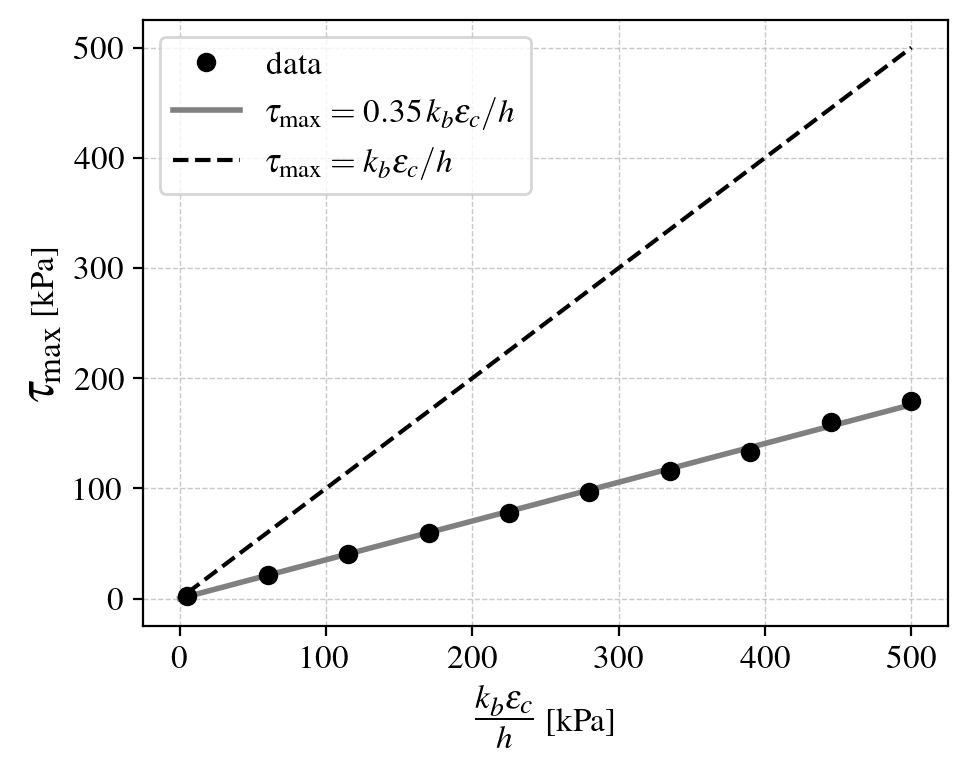

In [7]:
df = pd.read_parquet("data/strength_results.parquet")

x = df["eps"].to_numpy() * 1e9 / 1e3          # kN/m
y = df["max_shear_stress"].to_numpy() / 1e3  # kPa

# fit through the origin: y = m x
m = np.dot(x, y) / np.dot(x, x)

xfit = np.linspace(0, np.max(x), 200)
yfit = m * xfit

# predictions at data points
yhat = m * x

# through-origin R^2
ss_res = np.sum((y - yhat)**2)
ss_tot0 = np.sum(y**2)
r2 = 1 - ss_res / ss_tot0

plt.figure(figsize=(5,4))
plt.plot(x, y, "o", color = "k", label="data", zorder = 10)
plt.plot(xfit, yfit, "gray", lw = 2, label=fr"$\tau_{{\max}} = {m:.2f}\,k_b\epsilon_c/h$")
plt.plot(x, x, 'k--', label = r"$\tau_{{\max}} = k_b\epsilon_c/h$")
plt.xlabel(r"$\frac{k_b\epsilon_c}{h} \large {\text{  [kPa]}}$", size='x-large')
plt.ylabel(r"$\tau_{\max} \large {\text{  [kPa]}}$", size='x-large')
plt.tight_layout()
plt.legend()

plt.grid(linestyle="--", linewidth=0.5, color="0.7", alpha=0.7)

plt.savefig(os.path.join(output_directory, 'kbe2tau_smno.png'), dpi=300, bbox_inches='tight')
plt.show()

# Bond Stiffness and Shear/Elastic Modulus

Origin-constrained fit:
  E: slope = 0.473, R^2 = 1.0000
  G: slope = 0.178, R^2 = 1.0000


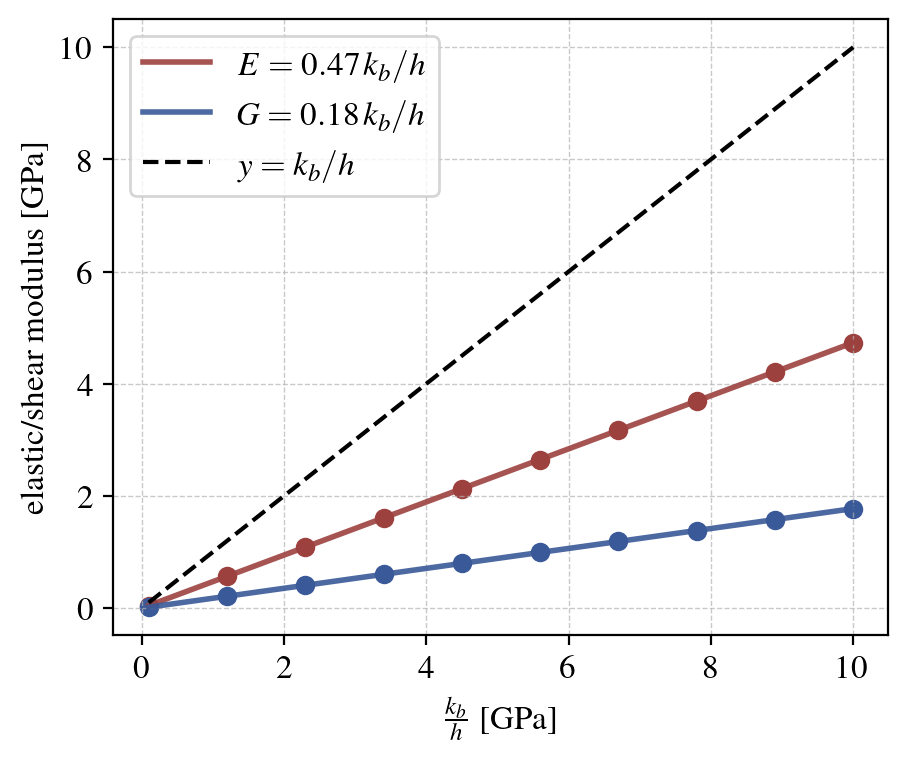

In [8]:
# ---- load parquet (cases mode) ----
df = pd.read_parquet("data/GE_results.parquet")

# ---- required columns ----
required_cols = ["kb", "E_mean", "G_mean"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in parquet.")

# ---- sort by kb ----
df = df.sort_values("kb").reset_index(drop=True)

# ---- extract and drop NaNs ----
sub = df[required_cols].dropna()

x_kb = sub["kb"].to_numpy(dtype=float)        # N/m
yE   = sub["E_mean"].to_numpy(dtype=float)    # Pa
yG   = sub["G_mean"].to_numpy(dtype=float)    # Pa

# ---- convert to plotted units ----
x = x_kb / 1e9   # GN/m
yE = yE   / 1e9  # GPa
yG = yG   / 1e9  # GPa

# ---- origin-constrained slopes: y = m x ----
den = np.sum(x**2)
mE = np.sum(x * yE) / den
mG = np.sum(x * yG) / den

yE_fit = mE * x
yG_fit = mG * x

# ---- R² for fits through the origin ----
R2_E = 1 - np.sum((yE - yE_fit)**2) / np.sum(yE**2)
R2_G = 1 - np.sum((yG - yG_fit)**2) / np.sum(yG**2)

print("Origin-constrained fit:")
print(f"  E: slope = {mE:.3g}, R^2 = {R2_E:.4f}")
print(f"  G: slope = {mG:.3g}, R^2 = {R2_G:.4f}")

label_E = rf"$E = {mE:.2g}\,k_b/h$"
label_G = rf"$G = {mG:.2g}\,k_b/h$"

# ---- plotting: scatter data, plot fit line ----
plt.figure(figsize=(5, 4))

# data (scatter only)

red = "#9d413f"
blue = "#3a5998"
plt.scatter(x, yE, color=red)
plt.scatter(x, yG, color=blue)

# fit lines on a smooth x-grid
xline = np.linspace(np.min(x), np.max(x), 200)
plt.plot(xline, mE * xline, color=red, label=label_E, lw = 2, alpha = 0.9)
plt.plot(xline, mG * xline, color=blue, label=label_G, lw = 2, alpha = 0.9)

# reference line y = kb (slope 1)
plt.plot(xline, xline, color="k", ls="--", label=r"$y = k_b/h$")

plt.xlabel(r"$\frac{k_b}{h}$ [GPa]")
plt.ylabel("elastic/shear modulus [GPa]")
plt.legend(frameon=True)

plt.grid(linestyle="--", linewidth=0.5, color="0.7", alpha=0.7)

plt.savefig(
    '/Users/arlenlex/Library/CloudStorage/OneDrive-Stanford/Stanford_Research/2025 Autumn/first_draft_paper_figs/kb2e_smno.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# Floe Generation Figure

In [9]:
fname = "data/lammps_data/N031475Dump_seed8095_1000hours.lammps"
pipeline = import_file(fname)

nframes = pipeline.source.num_frames
timesteps = []
avg_co = []
median_co = []
tau = []     

bin_edges = None
histograms = []   

# get data from lammps dump file
for frame in range(nframes):
    data = pipeline.compute(frame)

    # timestep
    ts = data.attributes.get("Timestep", frame)
    timesteps.append(float(ts))

    # coordination number
    if 'c_nbond' not in data.particles.keys():
        print(f"'c_nbond' not found at frame {frame}")
        continue

    co = np.asarray(data.particles['c_nbond'], dtype=float)

    if co.size == 0:
        print(f"No particles at frame {frame}")
        continue

    avg_co.append(co.mean())
    median_co.append(np.median(np.array(co)))

    # shear stress 
    if ('c_peratom_stress[4]' in data.particles.keys()):
        tau_xy_atoms = np.asarray(data.particles['c_peratom_stress[4]'], dtype=float)
        area = (100e3 * 100e3)
        shear_xy_mean = tau_xy_atoms.sum() / area
        tau.append(shear_xy_mean)
    else:
        tau.append(np.nan)

    # initialize bins if first pass
    if bin_edges is None:
        max_co = int(np.ceil(co.max()))
        bin_edges = np.arange(-0.5, max_co + 1.5, 1.0)

    # compute histogram for tframe
    h, _ = np.histogram(co, bins=bin_edges)

    # normalize to get fraction of particles instead of raw counts
    h = h.astype(float) / co.size
    histograms.append(h)

timesteps = np.array(timesteps)
histograms = np.array(histograms)    
tau = np.array(tau)   

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

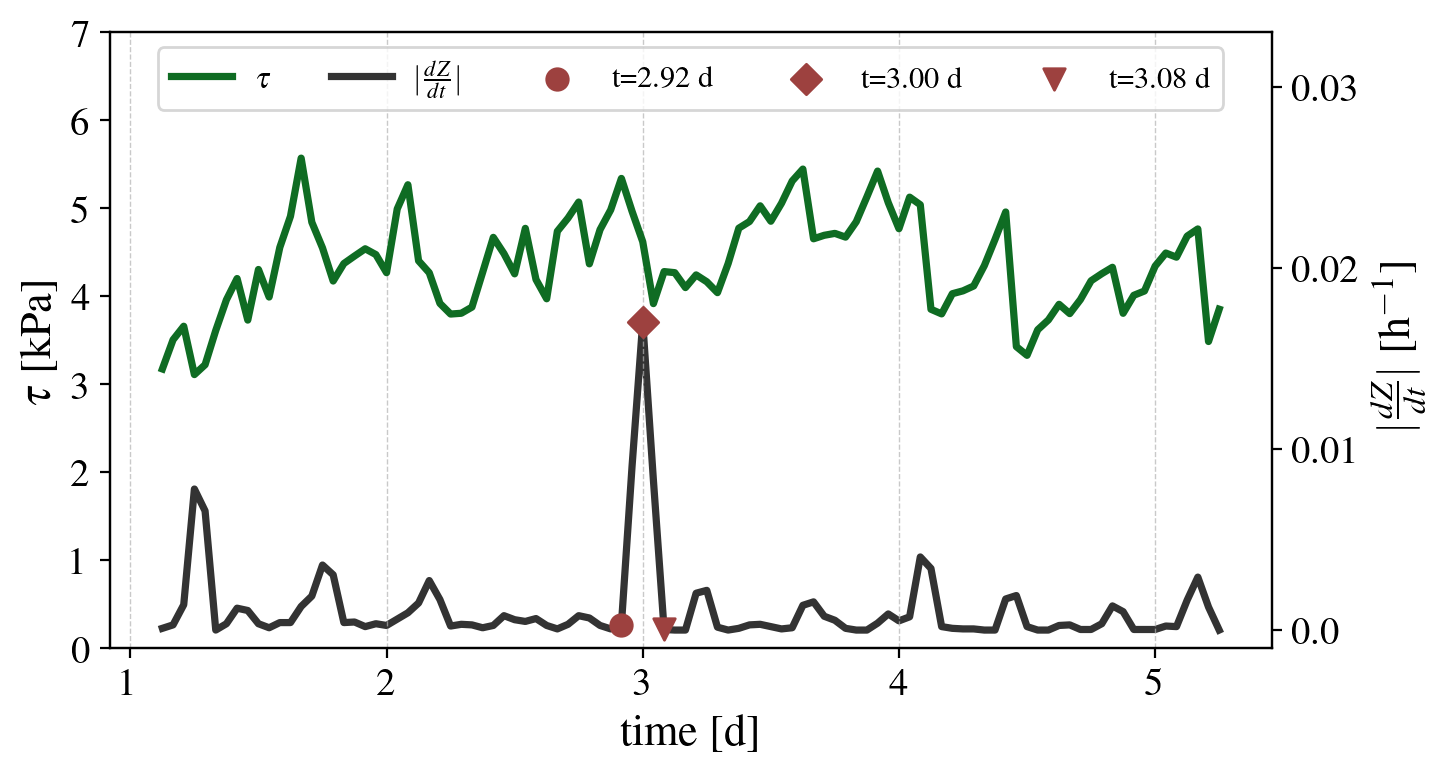

In [10]:
fig,ax_bottom = plt.subplots(1, figsize = (7.5,4))
start = 2
damage_rate = np.abs(np.gradient(np.array(avg_co), 1))[start:]

idx_min = 25
idx_max = 125

# damage_rate[i] corresponds to original index i + start
orig_slice = slice(start + idx_min, start + idx_max)
damage_slice = slice(idx_min, idx_max)

t_plot = timesteps[orig_slice] / 3600 * 0.025 / 24

ax_tau = ax_bottom.twinx()

line_tau, = ax_tau.plot(
    t_plot,
    tau[orig_slice] / 1000,
    color="#0f6c23",
    linewidth=2.6,
    label=r"$\tau$",
    zorder=1,
)

line_damage, = ax_bottom.plot(
    t_plot,
    damage_rate[damage_slice],
    color='0.2',
    linewidth=2.6,
    label=r"$|\frac{dZ}{dt}|$",
    zorder=0,
)


ax_tau.tick_params(axis="both", labelsize=14)
ax_bottom.tick_params(axis="both", labelsize=14)

ax_tau.set_ylabel(r"$\tau$ [kPa]", fontsize = 16)
ax_tau.yaxis.tick_left()
ax_tau.yaxis.set_label_position("left")

ax_bottom.set_xlabel("time [d]", fontsize = 16)
ax_bottom.set_ylabel(r"$|\frac{dZ}{dt}|$ [h$^{-1}$]", fontsize = 16)
ax_bottom.yaxis.tick_right()
ax_bottom.yaxis.set_label_position("right")

# marker times
t1, t2, t3 = 70, 72, 74
i1, i2, i3 = t1 - start, t2 - start, t3 - start

t1_day = timesteps[t1] / 3600 * 0.025 / 24
t2_day = timesteps[t2] / 3600 * 0.025 / 24
t3_day = timesteps[t3] / 3600 * 0.025 / 24

m1 = ax_bottom.scatter([t1_day], [damage_rate[i1]], marker='o', color='#9d413f', s = 60, label=f't={t1_day:.2f} d', zorder = 10)
m2 = ax_bottom.scatter([t2_day], [damage_rate[i2]], marker='D', color='#9d413f', s = 60, label=f't={t2_day:.2f} d', zorder = 11)
m3 = ax_bottom.scatter([t3_day], [damage_rate[i3]], marker='v', color='#9d413f', s = 60, label=f't={t3_day:.2f} d', zorder = 12)

handles = [line_tau, line_damage, m1, m2, m3]
labels = [h.get_label() for h in handles]

ax_bottom.legend(handles, labels, loc="upper center", ncol=5, frameon=True, fontsize=11)

ax_bottom.grid(axis='x', linestyle='--', linewidth=0.5, color='0.7', alpha=0.7)

ax_bottom.set_axisbelow(True)
ax_tau.set_axisbelow(True)

ax_tau.set_ylim(0, 7)
ax_bottom.set_ylim(-0.001, 0.033)
ax_bottom.set_yticks(np.linspace(0,0.03,4), np.linspace(0,0.03,4))
plt.savefig(os.path.join(output_directory, 'damage_ts_zoom_smno.png'), dpi=300, bbox_inches='tight')
plt.show()

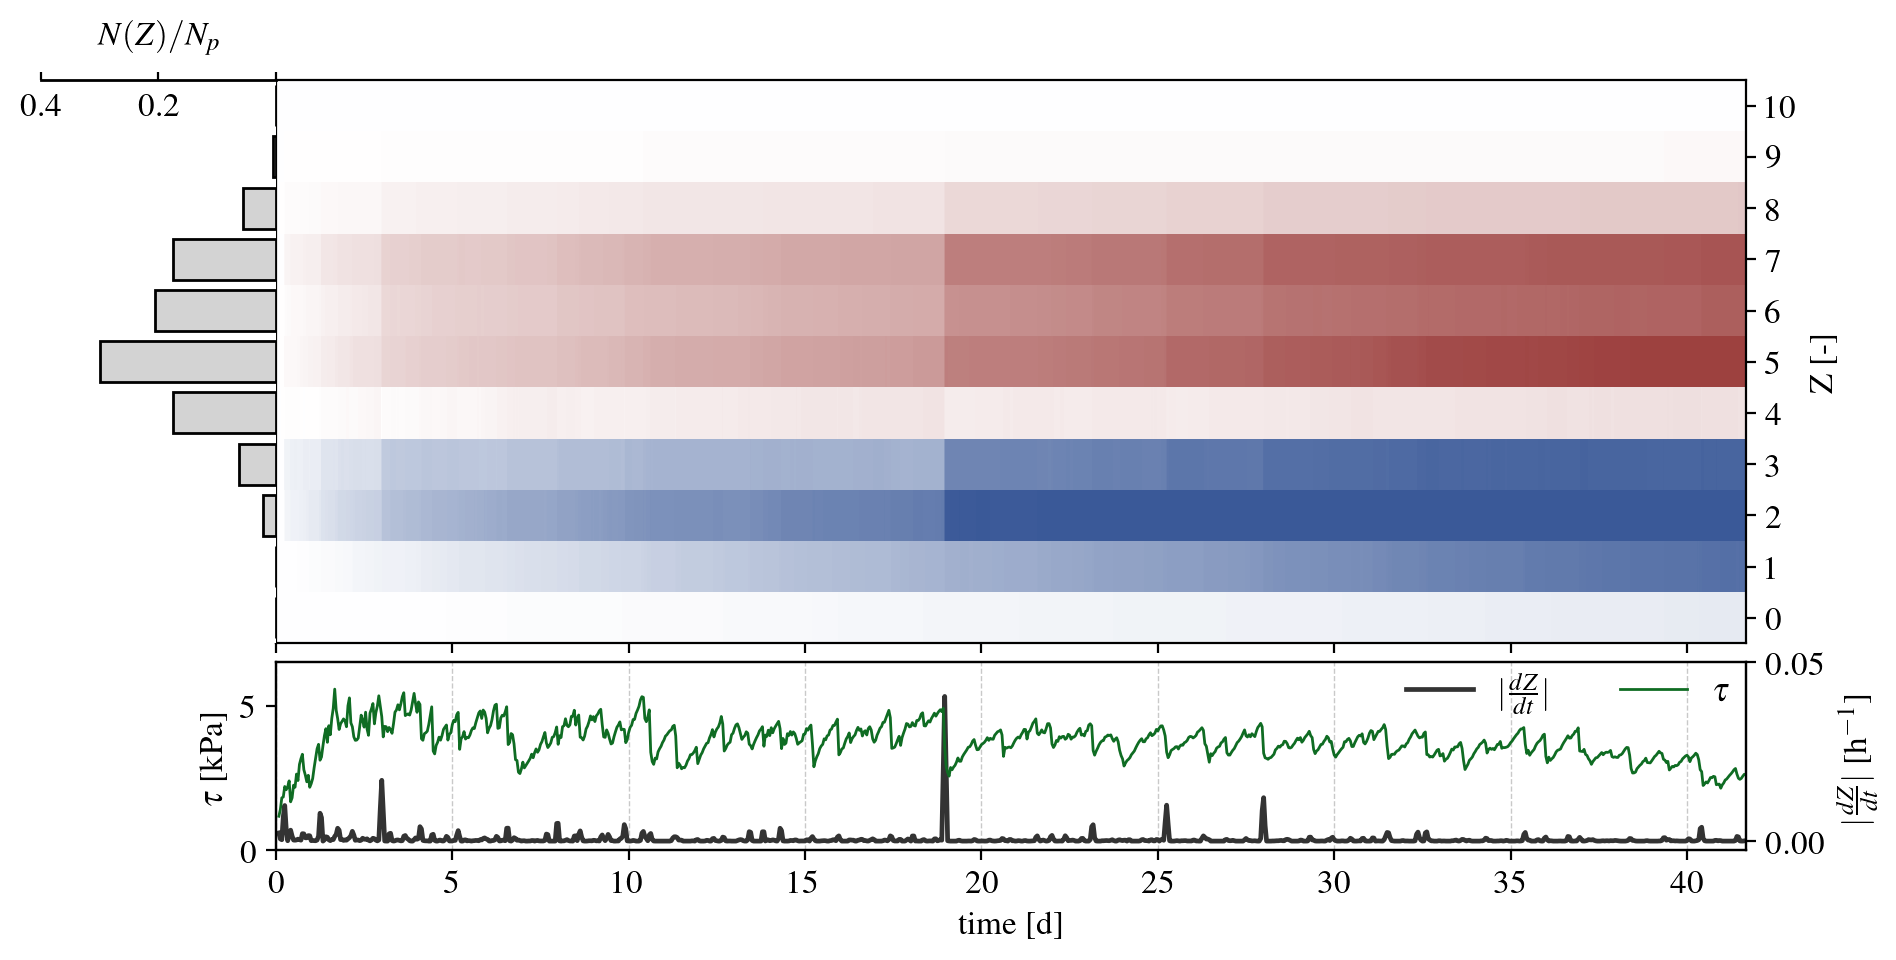

In [11]:
fig = plt.figure(figsize=(11, 5))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[0.8, 5],
    height_ratios=[3, 1],
    wspace=0.0,
    hspace=0.05,
)

# left column: histogram + dZ/dt
ax_top    = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_top)

# right column: heatmap + blank
ax_hist   = fig.add_subplot(gs[0, 0], sharey=ax_top)
ax       = fig.add_subplot(gs[1, 0])

# remove blank axis 
ax.remove()

# aggregate data
H = histograms[2:, :].astype(float).copy() # ignore first 2 timesteps (pre failure and at failure)
n_time, n_bins = H.shape

col_max = np.nanmax(H, axis=0)
col_max[col_max == 0] = 1
H_norm = H - H[0, :].reshape(1, n_bins)

y_edges = np.linspace(0, 10, 11)
t_hours = timesteps[2:] / 3600 * 0.025 / 24 # ignore first 2 timesteps 

custom_bwr = LinearSegmentedColormap.from_list(
    "indianred_white_slateblue",
    ["#9d413f", "white", "#3a5998"],
    N=256
)

# heatmap
im = ax_top.pcolormesh(
    t_hours,
    y_edges,
    H_norm.T,
    cmap=custom_bwr,
    vmin=-0.04,
    vmax=0.04,
    shading="auto",
)

ax_top.set_yticks(np.arange(n_bins))
ax_top.set_yticklabels([f"{int(v)}" for v in bin_centers])
ax_top.set_ylim(-0.5, n_bins - 0.5)
ax_top.tick_params(labelbottom=False)

ax_top.set_ylabel("Z [-]")
ax_top.yaxis.tick_right()
ax_top.yaxis.set_label_position("right")
ax_top.tick_params(
    axis="y",
    which="both",
    right=True, labelright=True,
    left=False, labelleft=False,
)

# damage rate and shear stress
damage_rate = np.abs(np.gradient(np.array(avg_co), 1))[2:] # 1000 dumps, 1000 hours, so dump every hour => dt = 1hr

cmap = plt.get_cmap(cmocean.cm.ice)
colors_icey = cmap(np.linspace(0,1,9))

# left: shear stress
ax_tau = ax_bottom.twinx()
ax_tau.plot(
    t_hours,
    tau[2:] / 1000,
    color="#0f6c23",
    alpha = 1,
    linewidth=1,
    label=r"$\tau$",
)
ax_tau.set_ylabel(r"$\tau$ [kPa]")
ax_tau.yaxis.tick_left()
ax_tau.yaxis.set_label_position("left")

# right: damage rate
ax_bottom.plot(
    t_hours,
    damage_rate,
    color='0.2',
    linewidth=1.7,
    alpha = 1,
    label=r"$|\frac{dZ}{dt}|$",
)
ax_bottom.set_xlabel("time [d]")
ax_bottom.set_ylim(-0.0025,0.05)
plt.sca(ax_bottom)
plt.xticks(np.linspace(0,45,10))
plt.xlim(0,t_hours[-1])
ax_bottom.set_ylabel(r"$|\frac{dZ}{dt}|$ [h$^{-1}$]")
ax_bottom.yaxis.tick_right()
ax_bottom.yaxis.set_label_position("right")

ymin, ymax = ax_tau.get_ylim()
ax_tau.set_ylim(0, 6.5)

# make legends
lines1, labels1 = ax_bottom.get_legend_handles_labels()
lines2, labels2 = ax_tau.get_legend_handles_labels()

ax_bottom.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc=(0.76, 0.66),
    ncol=2,
    frameon=False,
    fontsize='medium'
)

ax_bottom.grid(
    axis='x',           
    linestyle='--',
    linewidth=0.5,
    color='0.7',        
    alpha=0.7
)

ax_bottom.set_axisbelow(True)
ax_tau.set_axisbelow(True)

# histogram
h0 = H[0, :] # - show first timestep change

ax_hist.barh(
    np.arange(n_bins),
    -h0,                
    height=0.8,
    color="lightgray",
    edgecolor="black",
    zorder=2,
)

# get change from 0 to 2
h_ref = h0                 # reference (H[0, :], already plotted)
h_init = histograms[0, :]  # initial distribution

delta = h_init - h_ref

cmap = plt.get_cmap('bwr')
br = cmap(np.linspace(0,1,6))

ax_hist.set_ylim(ax_top.get_ylim())

# hide y-axis on histogram side only
ax_hist.tick_params(
    axis="y",
    which="both",
    left=False, right=False,
    labelleft=False, labelright=False,
)

# X axis with positive labels but bars going right→left
ax_hist.set_xticks([-0.4, -0.2, 0])
ax_hist.set_xticklabels(["0.4", "0.2", ""])
ax_hist.tick_params(axis='x', pad=-18)
xtlbls = ax_hist.get_xticklabels()
xtlbls[-1].set_horizontalalignment('right')
x, y = xtlbls[-1].get_position()
xtlbls[-1].set_position((x - 0.01, y))


ax_hist.xaxis.tick_top()
ax_hist.xaxis.set_label_position("top")
ax_hist.set_xlabel(r"$N(Z)/N_p$", labelpad=10)

# Only top spine
for s in ax_hist.spines.values():
    s.set_visible(False)
ax_hist.spines["top"].set_visible(True)
ax_hist.spines["top"].set_linewidth(1.0)

ax_hist.tick_params(axis='x', length=3)
ax_hist.tick_params(left=False)


plt.savefig(os.path.join(output_directory, 'damaging_incomplete_swapped_smno.png'), dpi=300, bbox_inches='tight')
plt.show()

In [12]:
def damage_peak_stress_drop_accuracy(
    tau,
    damage_rate,
    peak_prominence=None,
    peak_height=None,
    peak_distance=None
):
    """
    Check how often tau drops immediately after a damage-rate peak:
        tau[i+1] < tau[i]

    Parameters
    ----------
    tau : array-like
        Raw stress time series (unsmoothed).
    damage_rate : array-like
        Damage-rate time series.
    peak_prominence, peak_height, peak_distance :
        Passed to scipy.signal.find_peaks to define damage peaks.

    Returns
    -------
    results : dict
        Dictionary with peak indices and fraction of peaks followed by a stress drop.
    """
    tau = np.asarray(tau)
    damage_rate = np.asarray(damage_rate)

    if len(tau) != len(damage_rate):
        raise ValueError("tau and damage_rate must have the same length.")

    peaks, props = find_peaks(
        damage_rate,
        prominence=peak_prominence,
        height=peak_height,
        distance=peak_distance
    )

    # exclude final point since tau[i+1] does not exist
    usable_peaks = peaks[peaks < len(tau) - 2]

    if len(usable_peaks) == 0:
        return {
            "n_peaks": 0,
            "n_usable_peaks": 0,
            "n_followed_by_drop": 0,
            "fraction_followed_by_drop": np.nan,
            "percent_followed_by_drop": np.nan,
            "usable_peaks": usable_peaks,
        }

    drops = tau[usable_peaks + 1] < tau[usable_peaks]
    n_drop = np.sum(drops)
    frac = n_drop / len(usable_peaks)

    return {
        "n_peaks": len(peaks),
        "n_usable_peaks": len(usable_peaks),
        "n_followed_by_drop": int(n_drop),
        "fraction_followed_by_drop": frac,
        "percent_followed_by_drop": 100 * frac,
        "usable_peaks": usable_peaks,
        "drop_mask": drops,
        "tau_at_peak": tau[usable_peaks],
        "tau_next": tau[usable_peaks + 2],
        "peaks": peaks
    }
resy = []
for dist in (np.arange(20)+1):
    res = damage_peak_stress_drop_accuracy(
        tau=tau[2:],
        damage_rate=damage_rate,
        peak_prominence=0.0025,   
        peak_distance=dist
    )
    resy.append(res['percent_followed_by_drop'])
res = damage_peak_stress_drop_accuracy(
        tau=tau[2:],
        damage_rate=damage_rate,
        peak_prominence=0.0025,   
        peak_distance=6
    )
print(
    f"{res['percent_followed_by_drop']:.1f}% of damage peaks "
    f"are followed by an immediate drop in tau "
    f"({res['n_followed_by_drop']}/{res['n_usable_peaks']})."
)

86.4% of damage peaks are followed by an immediate drop in tau (19/22).


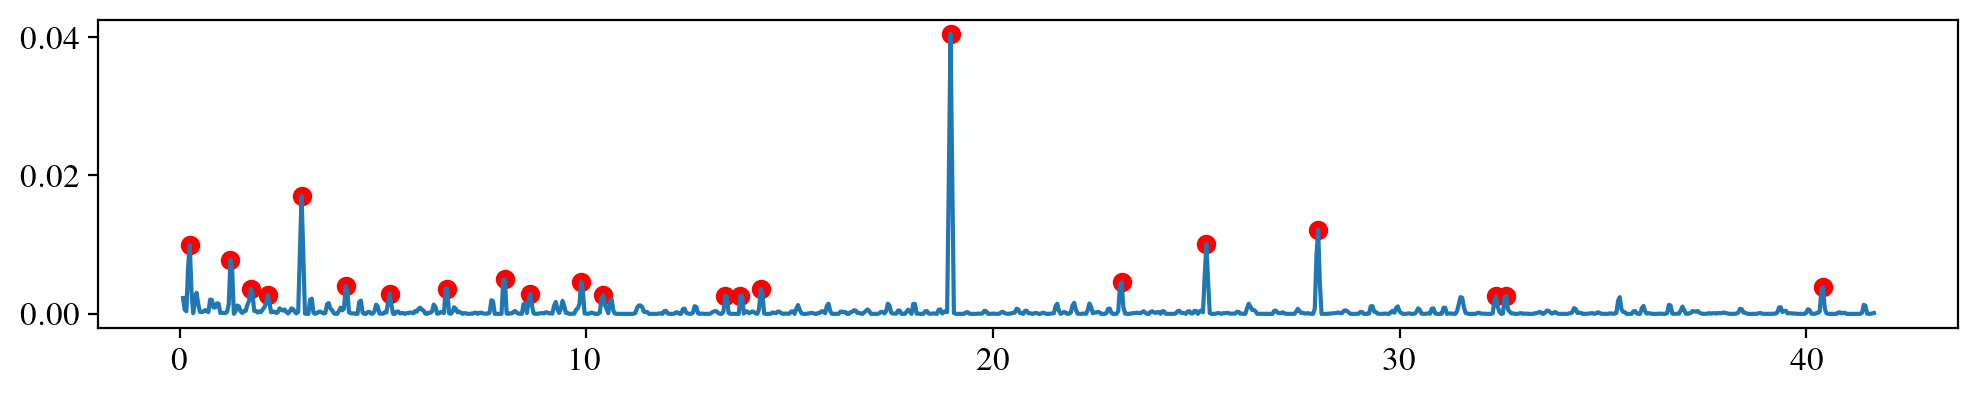

In [13]:
plt.figure(figsize=(12,2))
plt.scatter(t_hours[res['peaks']], damage_rate[res['peaks']], color = 'r')
plt.plot(t_hours, damage_rate)

# Unstable Arch

In [14]:
def get_ts_from_data(fname, dt, y_cutoff=120e3):
    """
    Load LAMMPS dump and compute dcodt and avg vy in the upper half.
    Returns: dcodt [arbitrary units per frame], avg_vy [m/s], time [s].
    """
    pipeline = import_file(fname)

    nframes = pipeline.source.num_frames
    timesteps = []
    avg_co = []
    avg_vy = []

    for frame in range(nframes):
        data = pipeline.compute(frame)

        # record timestep
        ts = data.attributes.get("Timestep", frame)
        timesteps.append(float(ts))

        # mean coordination number (active particles only)
        if 'c_nbond' in data.particles.keys() and 'v_ingroup' in data.particles.keys():
            co = data.particles['c_nbond']
            ingroup = data.particles['v_ingroup']
            mask = (ingroup == 1)
            filtered_co = co[mask]
            if len(filtered_co) > 0:
                avg_co.append(np.mean(filtered_co))
            else:
                print(f"No particles with v_ingroup == 1 at frame {frame}")
        else:
            print(f"Properties 'c_nbond' or 'v_ingroup' not found at frame {frame}")

        # velocity in upper half (active particles only)
        if 'Velocity' in data.particles.keys() and 'v_ingroup' in data.particles.keys():
            vy = data.particles['Velocity.Y']
            ypos = data.particles['Position.Y']
            v_ingroup = data.particles['v_ingroup']
            mask = (v_ingroup == 1) & (ypos >= y_cutoff)
            filtered_vy = vy[mask]
            if len(filtered_vy) > 0:
                avg_vy.append(np.mean(filtered_vy))
            else:
                print(f"No particles in upper half (y>={y_cutoff}) with v_ingroup == 1 at frame {frame}")
        else:
            print(f"Properties 'Velocity' or 'v_ingroup' not found at frame {frame}")

    dcodt = np.abs(np.gradient(np.array(avg_co), 36/500))  
    return dcodt, np.array(avg_vy), np.array(timesteps) * dt

In [15]:
fpath = 'data/lammps_data/regime_examples/unstable169.lammps'
kb = 998969920.0
dt = 0.1* np.sqrt((np.pi*240**2*920)/kb)
dcodt, vy_up, time = get_ts_from_data(fpath, dt)
times_critical = dt*np.array([862204, 901795, 1148139, 1196528,1711211 ]) / 3600
# corresponds to 195, 204, 260, 271, 388

In [16]:
times_critical = dt*np.array([1384082, 1447572, 1815814, 1885653,2476110 ]) / 3600
# corresponds to 217, 227, 285, 296, 389

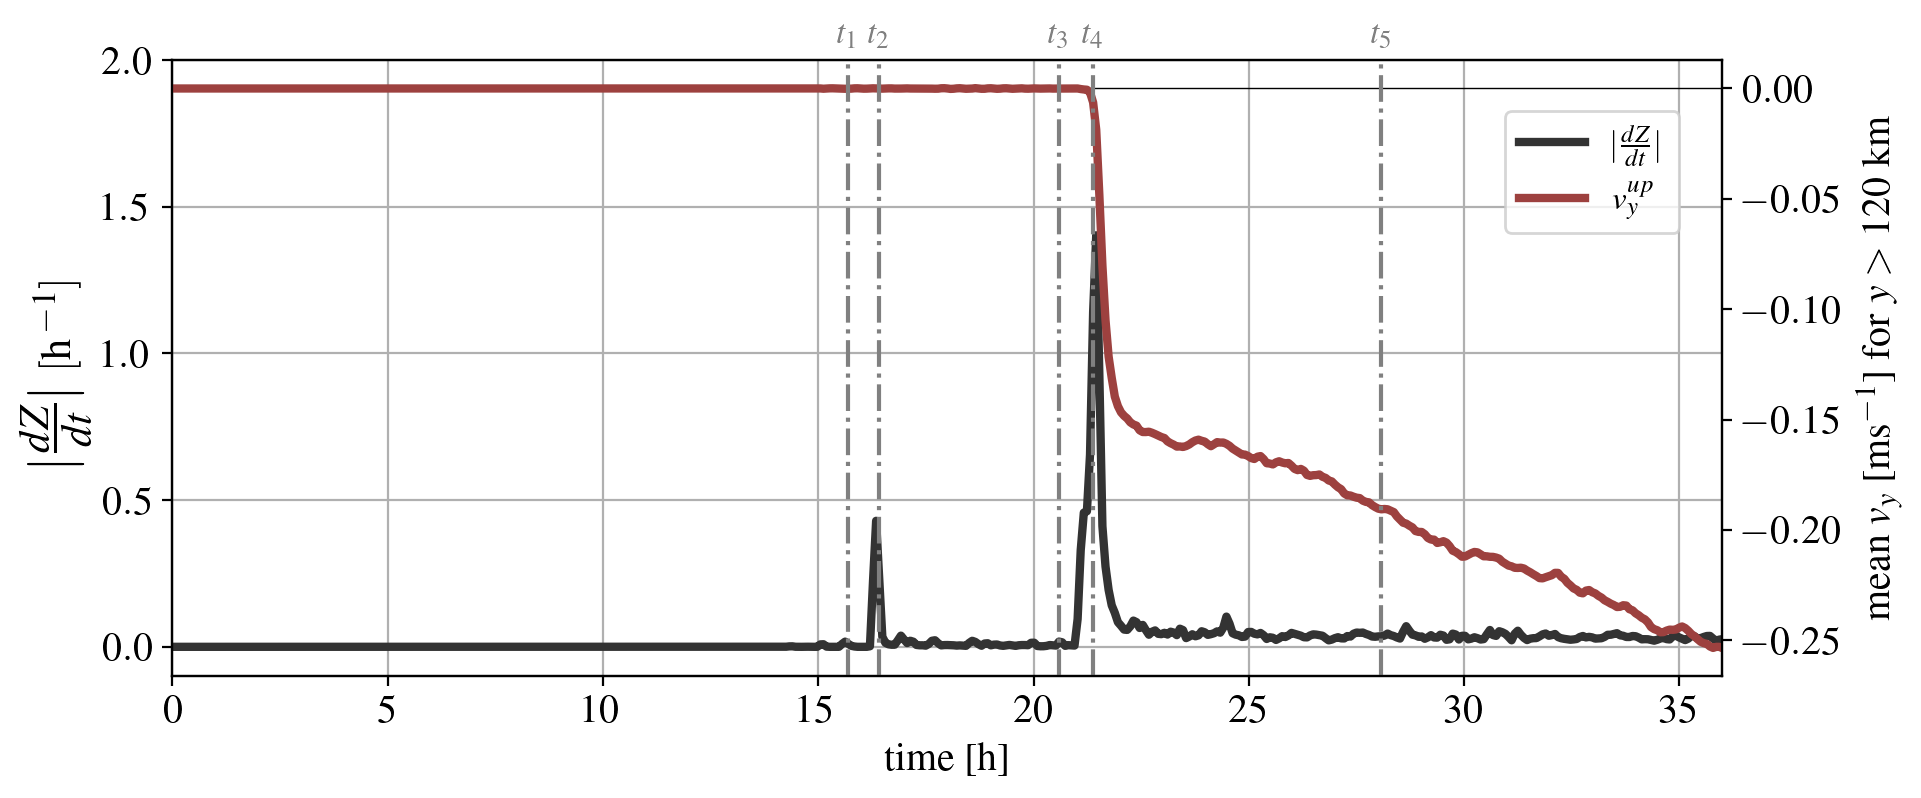

times_critical (hours):
[15.69506816 16.41502541 20.59077749 21.38273047 28.07833294]


In [17]:
fig, ax = plt.subplots(figsize=(10,4))

# --- primary axis ---
line1, = ax.plot(time/3600, dcodt, lw=3, color='0.2',
                 label=r'$|\frac{dZ}{dt}|$')

ax.set_xlabel("time [h]", size='large')
# ax.set_ylabel(r"$|\frac{dZ}{dt}|$ [h$^{-1}$]", size='xx-large')
ax.set_ylabel(r"$|\frac{dZ}{dt}|\;{\scriptstyle [\mathrm{h\,^{-1}}]}$", size="xx-large")
ax.set_xticks(ax.get_xticks())
ax.set_yticks(np.linspace(0,2,5))
ax.tick_params(labelsize='large')
ax.grid()
ax.set_ylim(-0.1, 2)

# --- secondary axis ---
ax2 = ax.twinx()
line2, = ax2.plot(time/3600, vy_up, lw=3, color='#9d413f',
                  label=r'$v_{y}^{up}$')

ax2.set_ylabel(r"mean $v_y$ [ms$^{-1}$] for $y>120$ km", size='large')
ax2.tick_params(labelsize='large')
ax2.axhline(0, color='k', lw=0.5, zorder=0)

# --- vertical lines + labels ---
y_top = ax2.get_ylim()[1]

for i, t in enumerate(times_critical, start=1):
    ax2.axvline(t, lw=1.5, color='gray', ls='-.')
    ax2.text(
        t, y_top+5e-3,
        rf'$t_{i}$',
        ha='center', va='bottom',
        fontsize='medium',
        color='gray',
        clip_on=False, zorder = 10
    )

# --- legend: only time-series ---
ax.legend([line1, line2],
          [line1.get_label(), line2.get_label()],
          loc=(0.86, 0.72))

ax.set_xlim(0, 36)
plt.savefig(os.path.join(output_directory, 'unstablets.png'), dpi=400, bbox_inches='tight')

plt.show()

# --- print values ---
print("times_critical (hours):")
print(np.array(times_critical))


# Representative Regimes Time Series Figure

In [18]:
def get_ts_from_data(fname, y_cutoff=120e3):
    """
    Load LAMMPS dump and compute:
      - dcodt: |d/dt (mean coordination # of ingroup particles)|
      - avg_vy: mean vy in upper half (ingroup & y >= y_cutoff)  [m/s]
      - avg_sigma1_up: mean max principal stress in upper half   [same units as v_sxx]
      - time: physical time [s]

    Principal stress σ1 is computed from per-particle
    v_sxx, v_sxy, v_syy as a 2D stress tensor.
    """
    pipeline = import_file(fname)

    nframes = pipeline.source.num_frames
    timesteps   = []
    avg_co      = []
    avg_vy      = []
    avg_sigma1  = []
    avg_sigma2 = []

    for frame in range(nframes):
        data = pipeline.compute(frame)

        # record timestep
        ts = data.attributes.get("Timestep", frame)
        timesteps.append(float(ts))

        # --- mean coordination number (active particles only) ---
        if 'c_nbond' in data.particles.keys() and 'v_ingroup' in data.particles.keys():
            co      = data.particles['c_nbond']
            ingroup = data.particles['v_ingroup']
            mask    = (ingroup == 1)
            filtered_co = co[mask]
            if len(filtered_co) > 0:
                avg_co.append(np.mean(filtered_co))
            else:
                print(f"[frame {frame}] No particles with v_ingroup == 1 for coordination.")
        else:
            print(f"[frame {frame}] Missing 'c_nbond' or 'v_ingroup' for coordination.")

        # --- velocity in upper half (active particles only) ---
        if 'Velocity' in data.particles.keys() and 'v_ingroup' in data.particles.keys():
            vy      = data.particles['Velocity.Y']
            ypos    = data.particles['Position.Y']
            ingroup = data.particles['v_ingroup']
            mask    = (ingroup == 1) & (ypos >= y_cutoff)
            filtered_vy = vy[mask]
            if len(filtered_vy) > 0:
                avg_vy.append(np.mean(filtered_vy))
            else:
                print(f"[frame {frame}] No particles in upper half (y>={y_cutoff}) with v_ingroup == 1 for vy.")
        else:
            print(f"[frame {frame}] Missing 'Velocity' or 'v_ingroup' for vy.")

        # --- principal stress σ1 in upper half (using v_sxx, v_sxy, v_syy) ---
        have_stress = all(k in data.particles.keys() for k in ('v_sxx', 'v_sxy', 'v_syy')) \
                      and 'v_ingroup' in data.particles.keys()
        if have_stress:
            sxx     = data.particles['v_sxx']
            sxy     = data.particles['v_sxy']
            syy     = data.particles['v_syy']
            ypos    = data.particles['Position.Y']
            ingroup = data.particles['v_ingroup']

            mask    = (ingroup == 1) 
            sxx_u   = sxx[mask]
            sxy_u   = sxy[mask]
            syy_u   = syy[mask]

            if len(sxx_u) > 0:
                # 2D principal stresses of [[sxx, sxy],[sxy, syy]]:
                half_trace = 0.5 * (sxx_u + syy_u)
                rad        = np.sqrt((0.5 * (sxx_u - syy_u))**2 + sxy_u**2)
                sigma1     = half_trace + rad      # max principal stress
                sigma2     = half_trace - rad
                avg_sigma1.append(np.mean(sigma1))
                avg_sigma2.append(np.mean(sigma2))
            else:
                print(f"[frame {frame}] No particles in upper half (y>={y_cutoff}) with v_ingroup == 1 for stress.")
        else:
            print(f"[frame {frame}] Missing v_sxx/v_sxy/v_syy or v_ingroup for stress at frame {frame}.")

    # convert lists to arrays
    avg_co     = np.array(avg_co)
    avg_vy     = np.array(avg_vy)
    avg_sigma1 = np.array(avg_sigma1)
    avg_sigma2 = np.array(avg_sigma2)
    timesteps  = np.array(timesteps)

    # damage rate 
    dt = (36*3600)/np.max(timesteps)
    time = timesteps * dt
    dt_dump = 36/500
    dcodt = np.abs(np.gradient(avg_co, dt_dump))

    return dcodt, avg_vy, avg_sigma1, avg_sigma2, time


In [19]:
def plot_damage_vs_principal_stress(ax, time, dcodt, sigma1, sigma2, leg, xaxis):
    """
    Single panel: damage rate (left y-axis) + principal stress (right y-axis).
    sigma1_up is the *average* σ1 in the upper half.
    """
    t_hrs = time / 3600.0

    # left axis: damage rate
    line1,  = ax.plot(t_hrs, dcodt, lw=3, color='0.2', label = r'$|\frac{dZ}{dt}|$')
    if xaxis:
        ax.set_xlabel('time [h]')
    ax.set_ylabel(r'$|\frac{dZ}{dt}|$ [h$^{-1}$]')
    ax.set_xlim(t_hrs.min(), t_hrs.max())
    ax.set_ylim(-0.1, 2)
    ax.grid(True, axis='both', linestyle='-', alpha=0.2)

    # right axis: principal stress
    ax2 = ax.twinx()
    # assume v_sxx etc are in Pa → convert to kPa; drop /1e3 if already in kPa
    line2,  = ax2.plot(t_hrs, sigma1 / 1e3, lw=2.5, ls='-', color="#3a5998", label = r'$\sigma_1$')
    line3,  = ax2.plot(t_hrs, sigma2 / 1e3, lw=2.5, ls='-', color="#9d413f", label = r'$\sigma_2$')
    ax2.axhline(0, color = 'k', lw = 0.5, zorder = 0)
    maxima = np.maximum(np.max(np.abs(sigma1)), np.max(np.abs(sigma2)))/1e3
    pad = 0.25
    ax2.set_ylim(-maxima - pad, maxima + pad)
    ax2.set_ylabel(r'$\sigma$ [kPa]')

    if leg:
        lines = [line1, line2, line3]
        labels = [line.get_label() for line in lines]
        ax.legend(lines, labels, loc='best', ncol = 4)


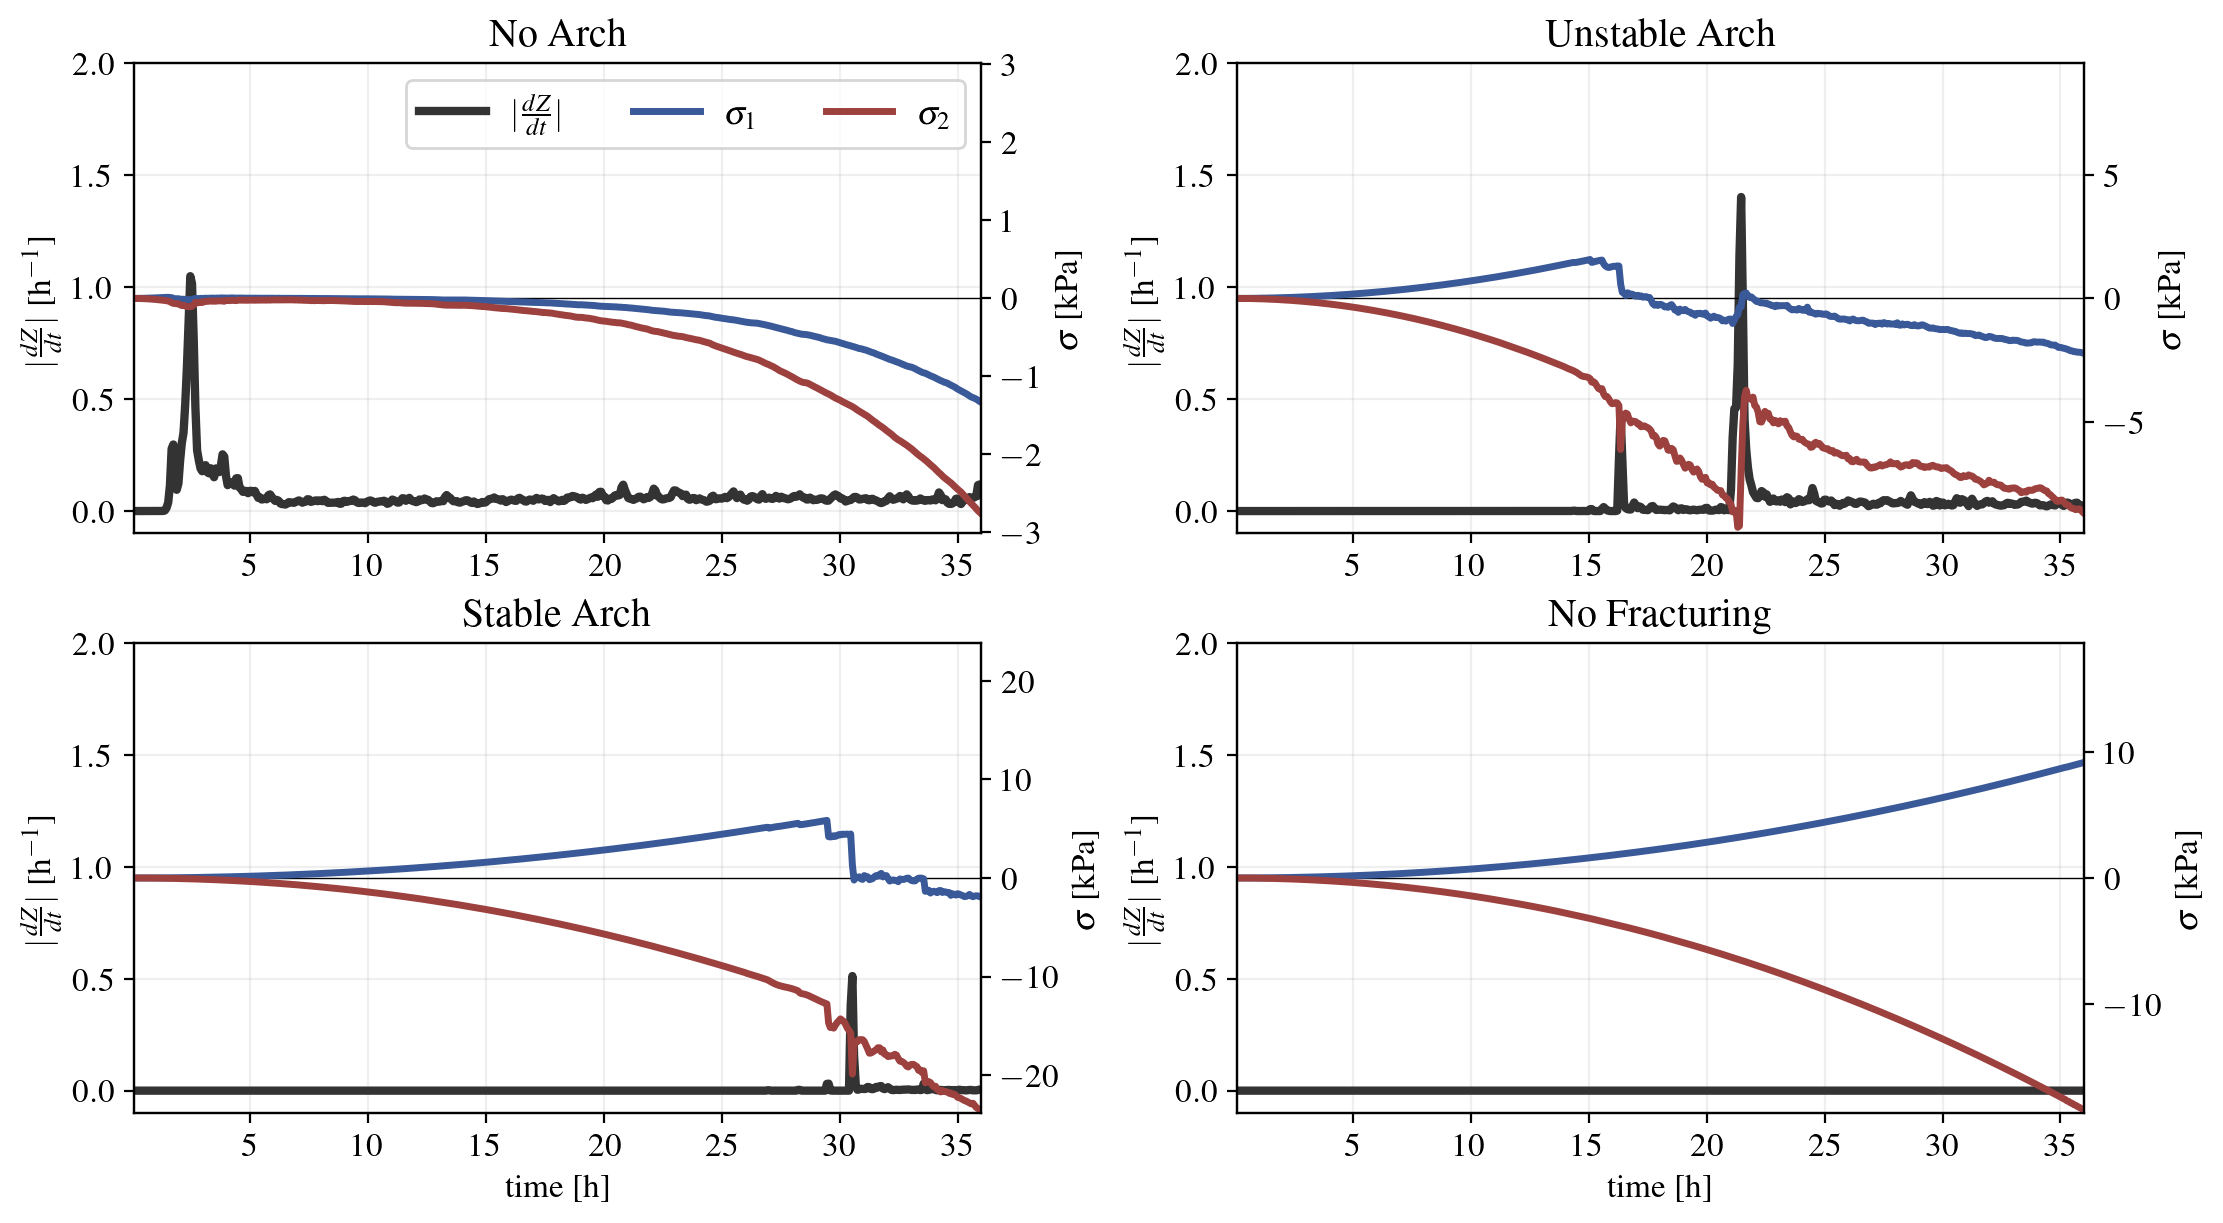

In [20]:
files = [
    ('data/lammps_data/regime_examples/noarch136.lammps', 'No Arch'),
    ('data/lammps_data/regime_examples/unstable169.lammps',  'Unstable Arch'),
    ('data/lammps_data/regime_examples/stable137.lammps', 'Stable Arch'),
    ('data/lammps_data/regime_examples/no_fracturing32.lammps',   'No Fracturing'),
]


fig, axes = plt.subplots(2,2, layout='constrained', figsize = (11,6))#, sharex=True)
axes = axes.ravel()

i = 0
for ax, (fname, label) in zip(axes, files):
    dcodt, vy_up, sigma1, sigma2, time = get_ts_from_data(fname, y_cutoff=120e3)
    leg = (i == 0)
    xaxis = (i >= 2)

    plot_damage_vs_principal_stress(ax, time, dcodt, sigma1, sigma2, leg, xaxis)
    i+=1
    ax.set_title(label)
plt.savefig(os.path.join(output_directory, 'damage_stress_ts.png'), dpi=300, bbox_inches='tight')
plt.show()

# Regimes

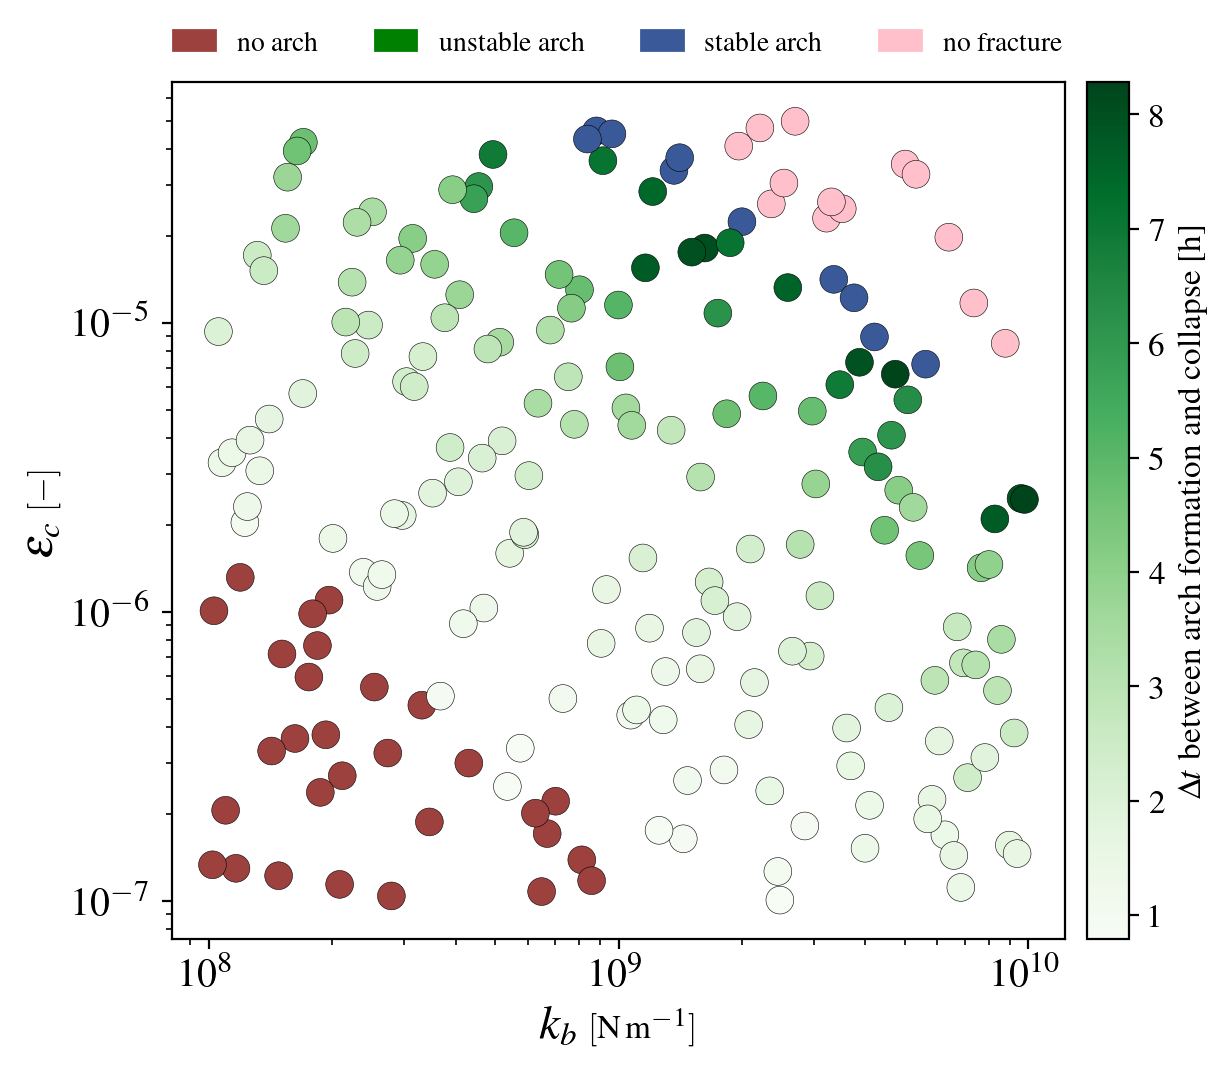

In [22]:
fpath = "data/state/regimes.parquet"
df = pd.read_parquet(fpath)

kb = df["kb"].to_numpy(float)
eps = df["eps"].to_numpy(float)
label = df["label"].to_numpy(int)

if "dt_h" in df.columns:
    dt_h = df["dt_h"].to_numpy(float)
elif ("y1_h" in df.columns) and ("y2_h" in df.columns):
    y1_h = df["y1_h"].to_numpy(float)
    y2_h = df["y2_h"].to_numpy(float)
    dt_h = np.abs(y2_h - y1_h)
    dt_h[label != 3] = np.nan
else:
    dt_h = np.full_like(kb, np.nan, dtype=float)

labels = {
    0: "no fracture",
    2: "no arch",
    1: "stable arch",
    3: "unstable arch",
}

fixed_cmap = ListedColormap(["pink", "#9d413f", "#3a5998", "g"])  

colors = np.zeros((kb.size, 4))
colors[label == 0] = fixed_cmap(0)  # pink
colors[label == 2] = fixed_cmap(1)  # red
colors[label == 1] = fixed_cmap(2)  # blue

reg3 = (label == 3) & np.isfinite(dt_h)
norm = None
if np.any(reg3):
    norm = Normalize(vmin=np.nanmin(dt_h[reg3]), vmax=np.nanmax(dt_h[reg3]))
    greens = plt.get_cmap("Greens")
    colors[reg3] = greens(norm(dt_h[reg3]))
else:
    colors[label == 3] = fixed_cmap(3)  # fallback solid green if no dt available

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(kb, eps, c=colors, s=100, edgecolor="k", linewidth=0.2)
# for i in range(len(kb)):
#     ax.text(kb[i], eps[i], f"{i+1}", fontsize = 10, color = 'k')

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$k_b\;{\scriptstyle [\mathrm{N\,m^{-1}}]}$", size="x-large")
ax.set_ylabel(r"$\epsilon_c\;{\scriptstyle [-]}$", size="x-large")
ax.tick_params(labelsize="large")

handles = [
    mpatches.Patch(color=fixed_cmap(1), label=labels[2]),
    mpatches.Patch(color=fixed_cmap(3), label=labels[3]),
    mpatches.Patch(color=fixed_cmap(2), label=labels[1]),
    mpatches.Patch(color=fixed_cmap(0), label=labels[0]),
]
ax.legend(
    handles=handles,
    frameon=False,
    fontsize="small",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.09),
    ncol=len(handles),
    handlelength=1.5,
)

if norm is not None:
    sm = plt.cm.ScalarMappable(norm=norm, cmap="Greens")
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"$\Delta t$ between arch formation and collapse [h]", rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(output_directory, 'regimes_parquet.png'), dpi=300, bbox_inches='tight')

plt.show()

# contact stiffness ensemble runs

In [ ]:
def get_ts_from_data(fname, y_cutoff=120e3):
    """
    Load LAMMPS dump and compute:
      - dcodt: |d/dt (mean coordination # of ingroup particles)|
      - avg_vy: mean vy in upper half (ingroup & y >= y_cutoff) [m/s]
      - avg_sigma1: mean max principal stress over ingroup particles
      - avg_sigma2: mean min principal stress over ingroup particles
      - time: physical time [s]

    Principal stresses are computed from per-particle
    v_sxx, v_sxy, v_syy as a 2D stress tensor.
    """
    pipeline = import_file(fname)

    nframes = pipeline.source.num_frames
    timesteps  = []
    avg_co     = []
    avg_vy     = []
    avg_sigma1 = []
    avg_sigma2 = []

    for frame in range(nframes):
        data = pipeline.compute(frame)

        # record timestep
        ts = data.attributes.get("Timestep", frame)
        timesteps.append(float(ts))

        keys = data.particles.keys()

        # --- mean coordination number: active particles only ---
        if 'c_nbond' in keys and 'v_ingroup' in keys:
            co = data.particles['c_nbond']
            ingroup = data.particles['v_ingroup']

            mask = (ingroup == 1)
            filtered_co = co[mask]

            if len(filtered_co) > 0:
                avg_co.append(np.mean(filtered_co))
            else:
                avg_co.append(np.nan)
                print(f"[frame {frame}] No particles with v_ingroup == 1 for coordination.")
        else:
            avg_co.append(np.nan)
            print(f"[frame {frame}] Missing 'c_nbond' or 'v_ingroup' for coordination.")

        # --- velocity in upper half: active particles only ---
        if 'Velocity' in keys and 'v_ingroup' in keys:
            vy = data.particles['Velocity.Y']
            ypos = data.particles['Position.Y']
            ingroup = data.particles['v_ingroup']

            mask = (ingroup == 1) & (ypos >= y_cutoff)
            filtered_vy = vy[mask]

            if len(filtered_vy) > 0:
                avg_vy.append(np.mean(filtered_vy))
            else:
                avg_vy.append(np.nan)
                print(f"[frame {frame}] No particles in upper half with v_ingroup == 1 for vy.")
        else:
            avg_vy.append(np.nan)
            print(f"[frame {frame}] Missing 'Velocity' or 'v_ingroup' for vy.")

        # --- principal stresses: active particles only ---
        have_stress = (
            all(k in keys for k in ('v_sxx', 'v_sxy', 'v_syy'))
            and 'v_ingroup' in keys
        )

        if have_stress:
            sxx = data.particles['v_sxx']
            sxy = data.particles['v_sxy']
            syy = data.particles['v_syy']
            ingroup = data.particles['v_ingroup']

            mask = (ingroup == 1)

            sxx_u = sxx[mask]
            sxy_u = sxy[mask]
            syy_u = syy[mask]

            if len(sxx_u) > 0:
                half_trace = 0.5 * (sxx_u + syy_u)
                rad = np.sqrt((0.5 * (sxx_u - syy_u))**2 + sxy_u**2)

                sigma1 = half_trace + rad
                sigma2 = half_trace - rad

                avg_sigma1.append(np.mean(sigma1))
                avg_sigma2.append(np.mean(sigma2))
            else:
                avg_sigma1.append(np.nan)
                avg_sigma2.append(np.nan)
                print(f"[frame {frame}] No particles with v_ingroup == 1 for stress.")
        else:
            avg_sigma1.append(np.nan)
            avg_sigma2.append(np.nan)
            print(f"[frame {frame}] Missing v_sxx/v_sxy/v_syy or v_ingroup for stress.")

    avg_co = np.asarray(avg_co, dtype=float)
    avg_vy = np.asarray(avg_vy, dtype=float)
    avg_sigma1 = np.asarray(avg_sigma1, dtype=float)
    avg_sigma2 = np.asarray(avg_sigma2, dtype=float)
    timesteps = np.asarray(timesteps, dtype=float)

    # Convert simulation timestep to physical time.
    # Assumes last timestep corresponds to 36 hours.
    dt = (36 * 3600) / np.max(timesteps)
    time = timesteps * dt

    # Damage rate.
    # If dumps are every 500 frames over 36 hours, dt_dump = 36/500 hours.
    dt_dump = 36 / 500
    dcodt = np.abs(np.gradient(avg_co, dt_dump))

    return dcodt, avg_vy, avg_sigma1, avg_sigma2, time


def plot_damage_vs_principal_stress(ax, time, dcodt, sigma1, sigma2, label, leg=False, xaxis=False):
    """
    Single panel: damage rate on left axis, principal stresses on right axis.
    """
    t_hrs = time / 3600.0

    # left axis: damage rate
    line1, = ax.plot(
        t_hrs, dcodt,
        lw=3,
        color='0.2',
        label=r'$|\frac{dZ}{dt}|$'
    )

    ax.set_ylabel(r'$|\frac{dZ}{dt}|$ [h$^{-1}$]')
    ax.set_xlim(t_hrs.min(), t_hrs.max())
    ax.set_ylim(-0.1, 2.5)
    ax.grid(True, axis='both', linestyle='-', alpha=0.2)

    if xaxis:
        ax.set_xlabel('time [h]')

    # right axis: principal stress
    ax2 = ax.twinx()

    line2, = ax2.plot(
        t_hrs, sigma1 / 1e3,
        lw=2.5,
        ls='-',
        color="#3a5998",
        label=r'$\sigma_1$'
    )

    line3, = ax2.plot(
        t_hrs, sigma2 / 1e3,
        lw=2.5,
        ls='-',
        color="#9d413f",
        label=r'$\sigma_2$'
    )

    ax2.axhline(0, color='k', lw=0.5, zorder=0)

    maxima = np.nanmax([
        np.nanmax(np.abs(sigma1)),
        np.nanmax(np.abs(sigma2))
    ]) / 1e3

    pad = 0.25
    ax2.set_ylim(-maxima - pad, maxima + pad)
    ax2.set_ylabel(r'$\sigma$ [kPa]')

    ax.set_title(label)

    if leg:
        lines = [line1, line2, line3]
        labels = [line.get_label() for line in lines]
        ax.legend(lines, labels, loc='best', ncol=3)


# ------------------------------------------------------------
# Files for varying contact stiffness
# ------------------------------------------------------------

base_dir = "data/lammps_data/kc_ensemble/lammps_output"

files = [
    ("dump1.lammps", r"$k_c = 10^5$"),
    ("dump2.lammps", r"$k_c = 10^6$"),
    ("dump3.lammps", r"$k_c = 10^7$"),
    ("dump4.lammps", r"$k_c = 10^8$"),
    ("dump5.lammps", r"$k_c = 10^9$"),
]

files = [(os.path.join(base_dir, fname), label) for fname, label in files]


# ------------------------------------------------------------
# Compute all time series once and store them
# ------------------------------------------------------------

results = {}

for fname, label in files:
    print(f"Processing {label}: {fname}")

    dcodt, vy_up, sigma1, sigma2, time = get_ts_from_data(
        fname,
        y_cutoff=120e3
    )

    results[label] = {
        "fname": fname,
        "time": time,
        "dcodt": dcodt,
        "vy_up": vy_up,
        "sigma1": sigma1,
        "sigma2": sigma2,
    }

Processing $k_c = 10^5$: /Users/arlenlex/Downloads/kc_ensemble_small/lammps_output/dump1.lammps
Processing $k_c = 10^6$: /Users/arlenlex/Downloads/kc_ensemble_small/lammps_output/dump2.lammps
Processing $k_c = 10^7$: /Users/arlenlex/Downloads/kc_ensemble_small/lammps_output/dump3.lammps
Processing $k_c = 10^8$: /Users/arlenlex/Downloads/kc_ensemble_small/lammps_output/dump4.lammps
Processing $k_c = 10^9$: /Users/arlenlex/Downloads/kc_ensemble_small/lammps_output/dump5.lammps


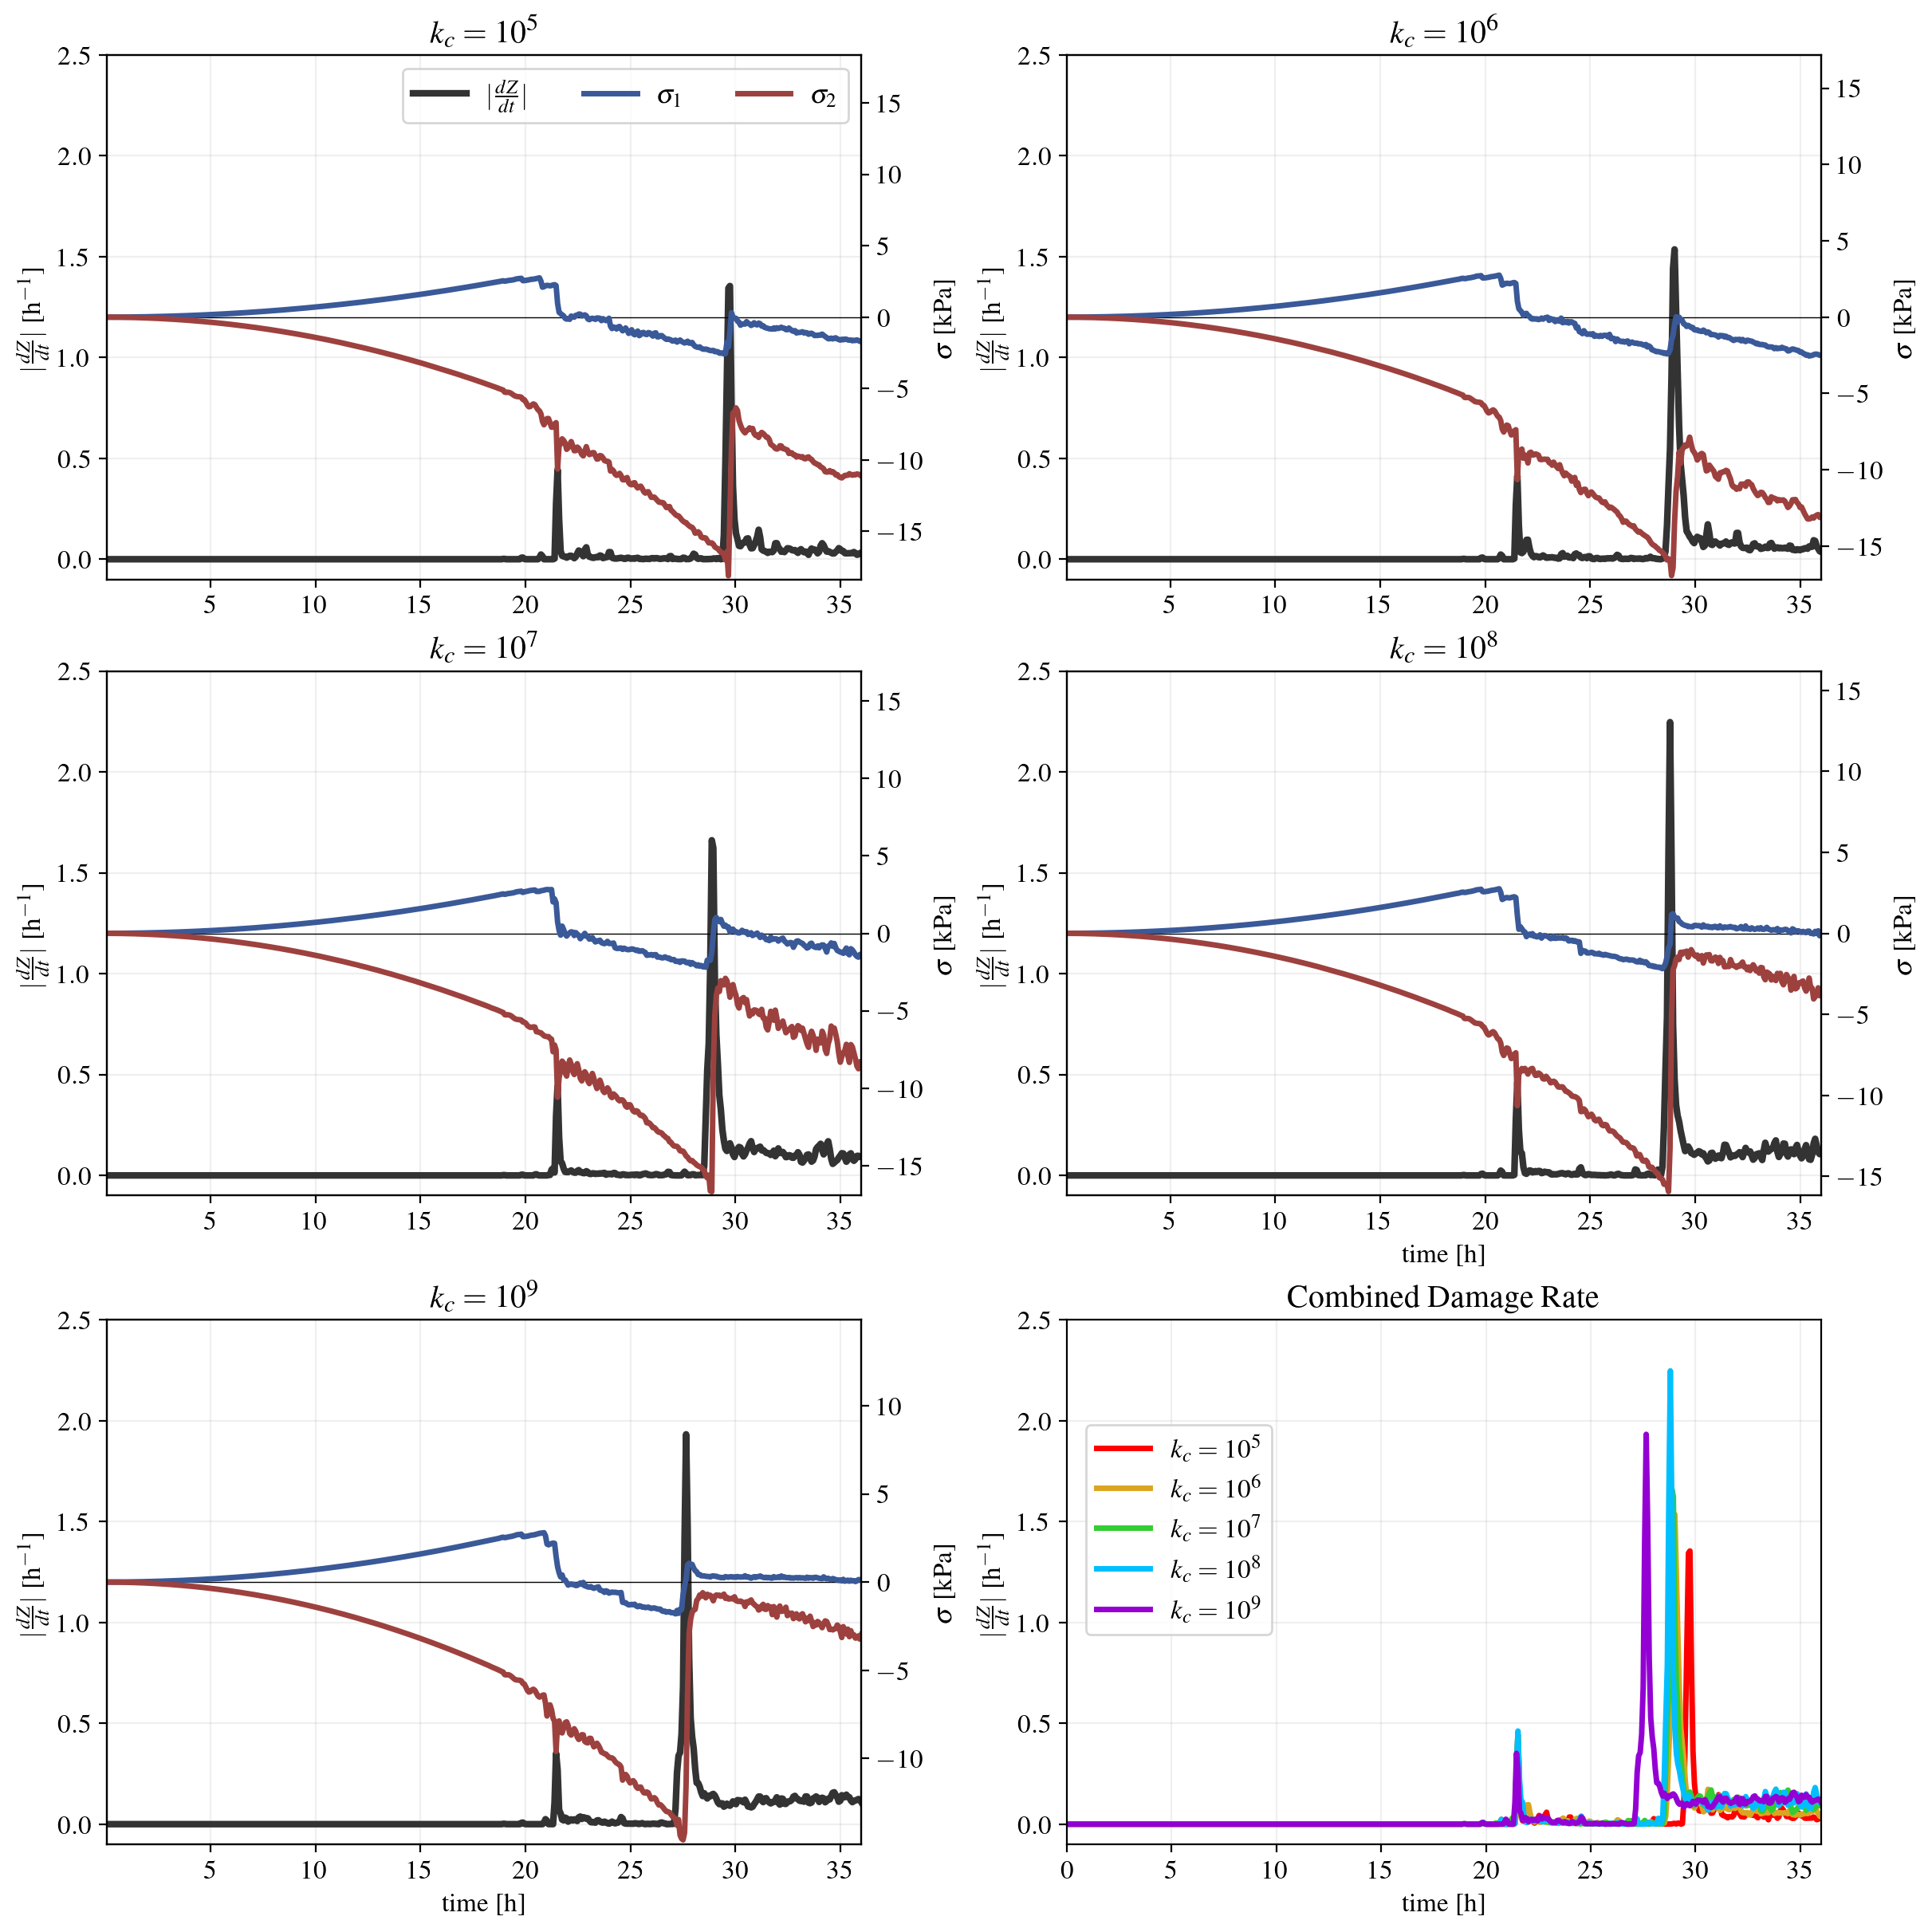

In [ ]:
# ------------------------------------------------------------
# Single figure: 2 x 3 layout
#   - first 5 panels: damage + stress for each kc
#   - last panel: overlay of damage rate for all kc
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 12),
    layout='constrained'
)

axes = axes.ravel()

# ------------------------------------------------------------
# First 5 subplots: individual kc panels
# ------------------------------------------------------------

for i, (ax, (fname, label)) in enumerate(zip(axes[:5], files)):
    r = results[label]

    plot_damage_vs_principal_stress(
        ax=ax,
        time=r["time"],
        dcodt=r["dcodt"],
        sigma1=r["sigma1"],
        sigma2=r["sigma2"],
        label=label,
        leg=(i == 0),
        xaxis=(i >= 3),   # bottom row only
    )

# ------------------------------------------------------------
# Sixth subplot: overlay damage rate for all kc values
# ------------------------------------------------------------

ax_overlay = axes[5]
colors = ['r', 'goldenrod', 'limegreen', 'deepskyblue', 'darkviolet']
i=0
for fname, label in files:
    r = results[label]
    t_hrs = r["time"] / 3600.0

    ax_overlay.plot(
        t_hrs,
        r["dcodt"],
        lw=2.5,
        label=label,
        color = colors[i]
    )
    i+=1

ax_overlay.set_title("Combined Damage Rate")
ax_overlay.set_xlabel("time [h]")
ax_overlay.set_ylabel(r"$|\frac{dZ}{dt}|$ [h$^{-1}$]")
ax_overlay.set_xlim(0, 36)
ax_overlay.set_ylim(-0.1, 2.5)
ax_overlay.grid(True, axis='both', linestyle='-', alpha=0.2)
ax_overlay.legend(fontsize=12, loc = (0.025, 0.4), ncols =1)

fig.savefig(os.path.join(output_directory, "damage_stress_kc_2x3.png"), dpi=300, bbox_inches='tight')
plt.show()

# contact stiffness regime checks

In [ ]:
def get_ts_from_data(fname, y_cutoff=120e3):
    """
    Load LAMMPS dump and compute:
      - dcodt: |d/dt (mean coordination # of ingroup particles)|
      - avg_vy: mean vy in upper half (ingroup & y >= y_cutoff)  [m/s]
      - avg_sigma1_up: mean max principal stress in upper half   [same units as v_sxx]
      - time: physical time [s]

    Principal stress σ1 is computed from per-particle
    v_sxx, v_sxy, v_syy as a 2D stress tensor.
    """
    pipeline = import_file(fname)

    nframes = pipeline.source.num_frames
    timesteps   = []
    avg_co      = []
    avg_vy      = []
    avg_sigma1  = []
    avg_sigma2 = []

    for frame in range(nframes):
        data = pipeline.compute(frame)

        # record timestep
        ts = data.attributes.get("Timestep", frame)
        timesteps.append(float(ts))

        # --- mean coordination number (active particles only) ---
        if 'c_nbond' in data.particles.keys() and 'v_ingroup' in data.particles.keys():
            co      = data.particles['c_nbond']
            ingroup = data.particles['v_ingroup']
            mask    = (ingroup == 1)
            filtered_co = co[mask]
            if len(filtered_co) > 0:
                avg_co.append(np.mean(filtered_co))
            else:
                print(f"[frame {frame}] No particles with v_ingroup == 1 for coordination.")
        else:
            print(f"[frame {frame}] Missing 'c_nbond' or 'v_ingroup' for coordination.")

        # --- velocity in upper half (active particles only) ---
        if 'Velocity' in data.particles.keys() and 'v_ingroup' in data.particles.keys():
            vy      = data.particles['Velocity.Y']
            ypos    = data.particles['Position.Y']
            ingroup = data.particles['v_ingroup']
            mask    = (ingroup == 1) & (ypos >= y_cutoff)
            filtered_vy = vy[mask]
            if len(filtered_vy) > 0:
                avg_vy.append(np.mean(filtered_vy))
            else:
                print(f"[frame {frame}] No particles in upper half (y>={y_cutoff}) with v_ingroup == 1 for vy.")
        else:
            print(f"[frame {frame}] Missing 'Velocity' or 'v_ingroup' for vy.")

        # --- principal stress σ1 in upper half (using v_sxx, v_sxy, v_syy) ---
        have_stress = all(k in data.particles.keys() for k in ('v_sxx', 'v_sxy', 'v_syy')) \
                      and 'v_ingroup' in data.particles.keys()
        if have_stress:
            sxx     = data.particles['v_sxx']
            sxy     = data.particles['v_sxy']
            syy     = data.particles['v_syy']
            ypos    = data.particles['Position.Y']
            ingroup = data.particles['v_ingroup']

            mask    = (ingroup == 1) 
            sxx_u   = sxx[mask]
            sxy_u   = sxy[mask]
            syy_u   = syy[mask]

            if len(sxx_u) > 0:
                # 2D principal stresses of [[sxx, sxy],[sxy, syy]]:
                half_trace = 0.5 * (sxx_u + syy_u)
                rad        = np.sqrt((0.5 * (sxx_u - syy_u))**2 + sxy_u**2)
                sigma1     = half_trace + rad      # max principal stress
                sigma2     = half_trace - rad
                avg_sigma1.append(np.mean(sigma1))
                avg_sigma2.append(np.mean(sigma2))
            else:
                print(f"[frame {frame}] No particles in upper half (y>={y_cutoff}) with v_ingroup == 1 for stress.")
        else:
            print(f"[frame {frame}] Missing v_sxx/v_sxy/v_syy or v_ingroup for stress at frame {frame}.")

    # convert lists to arrays
    avg_co     = np.array(avg_co)
    avg_vy     = np.array(avg_vy)
    avg_sigma1 = np.array(avg_sigma1)
    avg_sigma2 = np.array(avg_sigma2)
    timesteps  = np.array(timesteps)

    # damage rate 
    dt = (36*3600)/np.max(timesteps)
    time = timesteps * dt
    dt_dump = 36/500
    dcodt = np.abs(np.gradient(avg_co, dt_dump))

    return dcodt, avg_vy, avg_sigma1, avg_sigma2, time


In [ ]:
def plot_damage_vs_principal_stress(
    ax,
    solid_data,
    dashed_data=None,
    leg=False,
    xaxis=False
):
    """
    Single panel with:
      solid  = kc = 1e9
      dashed = kc = 1e5
    """

    dcodt, sigma1, sigma2, time = solid_data
    t_hrs = time / 3600.0

    # ---------- solid data ----------
    line1, = ax.plot(
        t_hrs, dcodt,
        lw=2.5, color='0.2', ls='-',
        label=r'$|\frac{dZ}{dt}|$', alpha = 0.8
    )

    ax2 = ax.twinx()

    line2, = ax2.plot(
        t_hrs, sigma1 / 1e3,
        lw=2, ls='-', color="#3a5998",
        label=r'$\sigma_1$', alpha = 0.8
    )

    line3, = ax2.plot(
        t_hrs, sigma2 / 1e3,
        lw=2, ls='-', color="#9d413f",
        label=r'$\sigma_2$', alpha = 0.8
    )

    # ---------- dashed data ----------
    dashed_lines = []

    if dashed_data is not None:
        dcodt_d, sigma1_d, sigma2_d, time_d = dashed_data
        t_hrs_d = time_d / 3600.0

        line1d, = ax.plot(
            t_hrs_d, dcodt_d,
            lw=2.5, color='0.2', ls='--',
            label=r'$|\frac{dZ}{dt}|$'
        )

        line2d, = ax2.plot(
            t_hrs_d, sigma1_d / 1e3,
            lw=2, ls='--', color="#3a5998",
            label=r'$\sigma_1$'
        )

        line3d, = ax2.plot(
            t_hrs_d, sigma2_d / 1e3,
            lw=2, ls='--', color="#9d413f",
            label=r'$\sigma_2$'
        )

        dashed_lines = [line1d, line2d, line3d]

    # ---------- axes ----------
    if xaxis:
        ax.set_xlabel('time [h]')

    ax.set_ylabel(r'$|\frac{dZ}{dt}|$ [h$^{-1}$]')
    ax.set_xlim(t_hrs.min(), t_hrs.max())
    ax.set_ylim(-0.1, 3)
    ax.grid(True, axis='both', linestyle='-', alpha=0.2)

    ax2.axhline(0, color='k', lw=0.5, zorder=0)

    all_sigmas = [sigma1, sigma2]
    if dashed_data is not None:
        all_sigmas += [sigma1_d, sigma2_d]

    maxima = max(np.max(np.abs(s)) for s in all_sigmas) / 1e3
    pad = 0.25
    ax2.set_ylim(-maxima - pad, maxima + pad)
    ax2.set_ylabel(r'$\sigma$ [kPa]')

    # ---------- legend ----------
    if leg:
        solid_lines = [line1, line2, line3]

        if dashed_data is not None:
            handles = solid_lines + dashed_lines
            labels = (
                [r'$|\frac{dZ}{dt}|$', r'$\sigma_1$', r'$\sigma_2$'] +
                [r'$|\frac{dZ}{dt}|$', r'$\sigma_1$', r'$\sigma_2$']
            )

            leg = ax.legend(
                handles,
                labels,
                ncol=2,
                title=(
                    r'$k_c = 10^9$ Nm$^{-1}$'
                    + ' ' * 18 +
                    r'$k_c = 10^5$ Nm$^{-1}$'
                ),
                loc='best', fontsize = 10
            )
        else:
            ax.legend(solid_lines, [l.get_label() for l in solid_lines], loc='best')

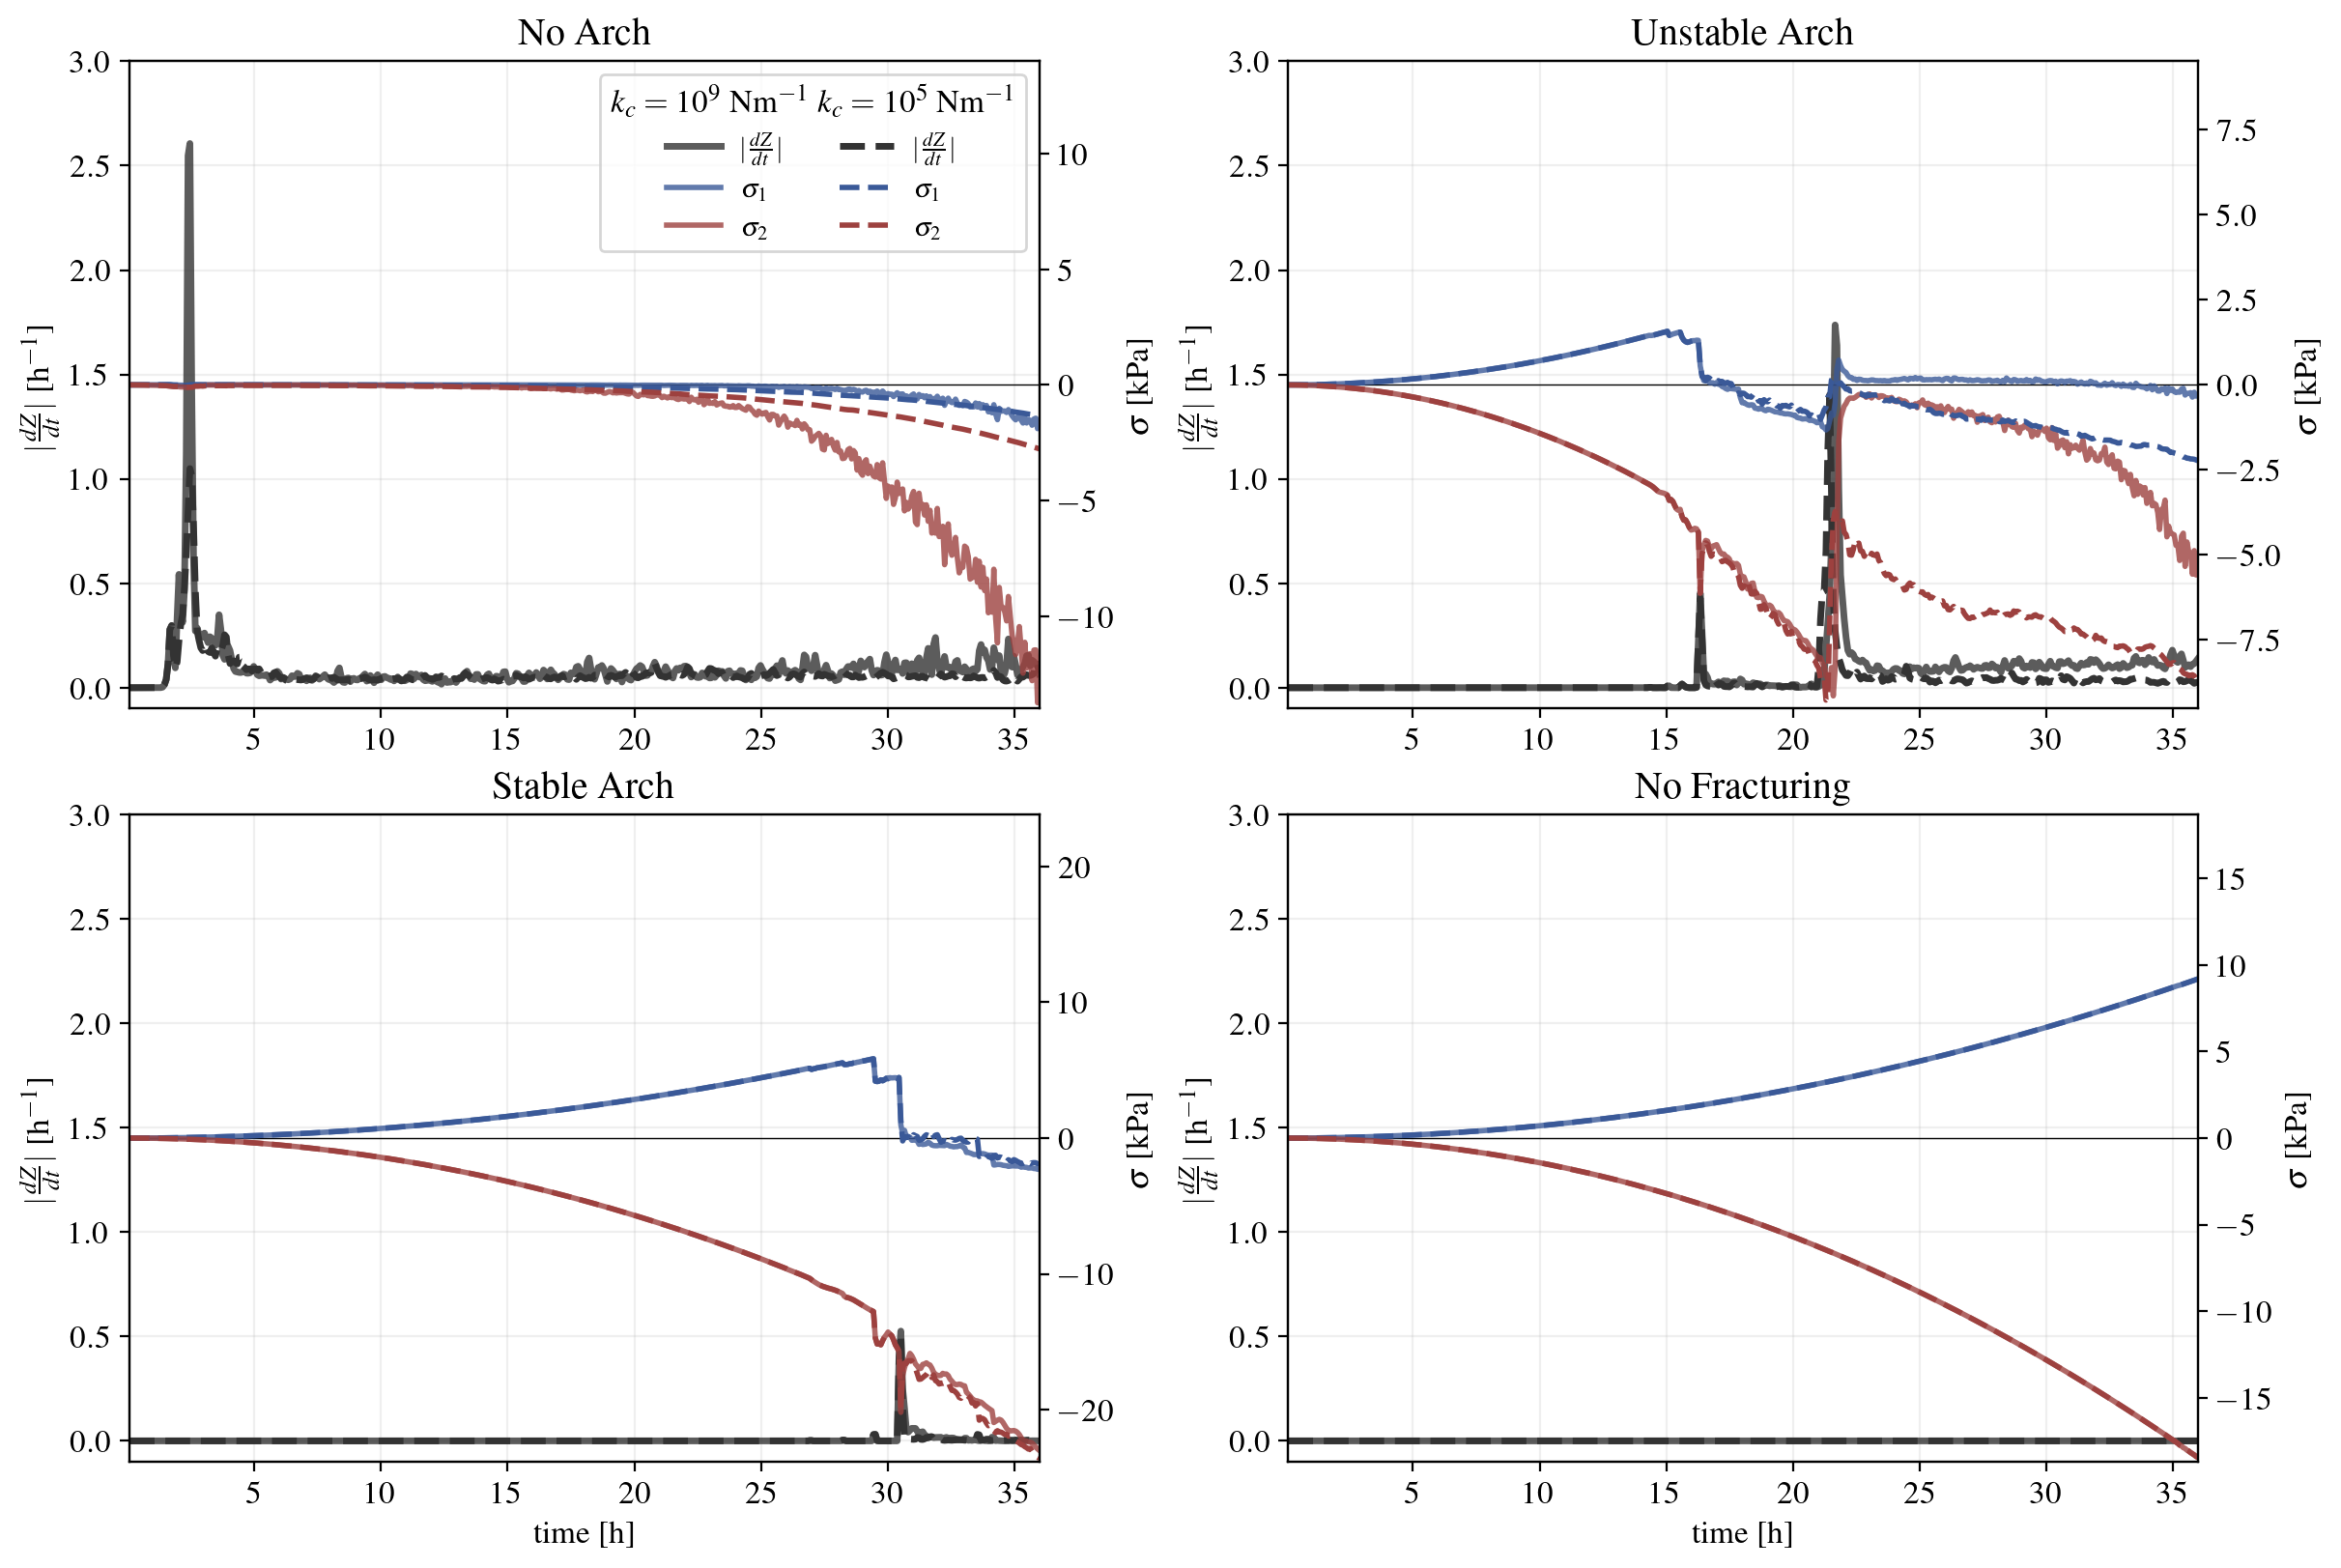

In [ ]:
files_solid = [
    ('data/lammps_data/kc1e9_regime_checks/lammps_output/dump1.lammps', 'No Arch'),
    ('data/lammps_data/kc1e9_regime_checks/lammps_output/dump2.lammps', 'Unstable Arch'),
    ('data/lammps_data/kc1e9_regime_checks/lammps_output/dump3.lammps', 'Stable Arch'),
    ('data/lammps_data/kc1e9_regime_checks/lammps_output/dump4.lammps', 'No Fracturing'),
]

files_dashed = [
    ('data/lammps_data/regime_examples/noarch136.lammps', 'No Arch'),
    ('data/lammps_data/regime_examples/unstable169.lammps',  'Unstable Arch'),
    ('data/lammps_data/regime_examples/stable137.lammps', 'Stable Arch'),
    ('data/lammps_data/regime_examples/no_fracturing32.lammps',   'No Fracturing'),
]


fig, axes = plt.subplots(2, 2, layout='constrained', figsize=(12, 8))
axes = axes.ravel()

for i, (ax, solid_item, dashed_item) in enumerate(zip(axes, files_solid, files_dashed)):
    fname_solid, label = solid_item
    fname_dashed, _ = dashed_item

    dcodt, vy_up, sigma1, sigma2, time = get_ts_from_data(fname_solid, y_cutoff=120e3)
    solid_data = (dcodt, sigma1, sigma2, time)

    dcodt_d, vy_up_d, sigma1_d, sigma2_d, time_d = get_ts_from_data(fname_dashed, y_cutoff=120e3)
    dashed_data = (dcodt_d, sigma1_d, sigma2_d, time_d)

    leg = (i == 0)
    xaxis = (i >= 2)

    plot_damage_vs_principal_stress(
        ax,
        solid_data,
        dashed_data=dashed_data,
        leg=leg,
        xaxis=xaxis
    )

    ax.set_title(label)

plt.savefig(os.path.join(output_directory,'damage_stress_ts_kc_compare.png'), dpi=300, bbox_inches='tight')

plt.show()

# compute time

CPU-hour performance summary:
     873 atoms |  10 runs | mean CPU-hours = 0.0006
    1257 atoms |  10 runs | mean CPU-hours = 0.0008
    2237 atoms |  10 runs | mean CPU-hours = 0.0017
    3496 atoms |  10 runs | mean CPU-hours = 0.0029
   13987 atoms |  10 runs | mean CPU-hours = 0.0259
   31475 atoms |  10 runs | mean CPU-hours = 0.1304
   55954 atoms |  10 runs | mean CPU-hours = 0.2440
   87431 atoms |  10 runs | mean CPU-hours = 0.3832
  125900 atoms |  10 runs | mean CPU-hours = 1.0628
  171366 atoms |  10 runs | mean CPU-hours = 1.5355
  223824 atoms |  10 runs | mean CPU-hours = 2.0905
  283279 atoms |  10 runs | mean CPU-hours = 2.7610

Power-law fit:
CPU-hours: c(N) = 1.497e-08 * N^1.521 (R^2 in log-log space = 0.9972)


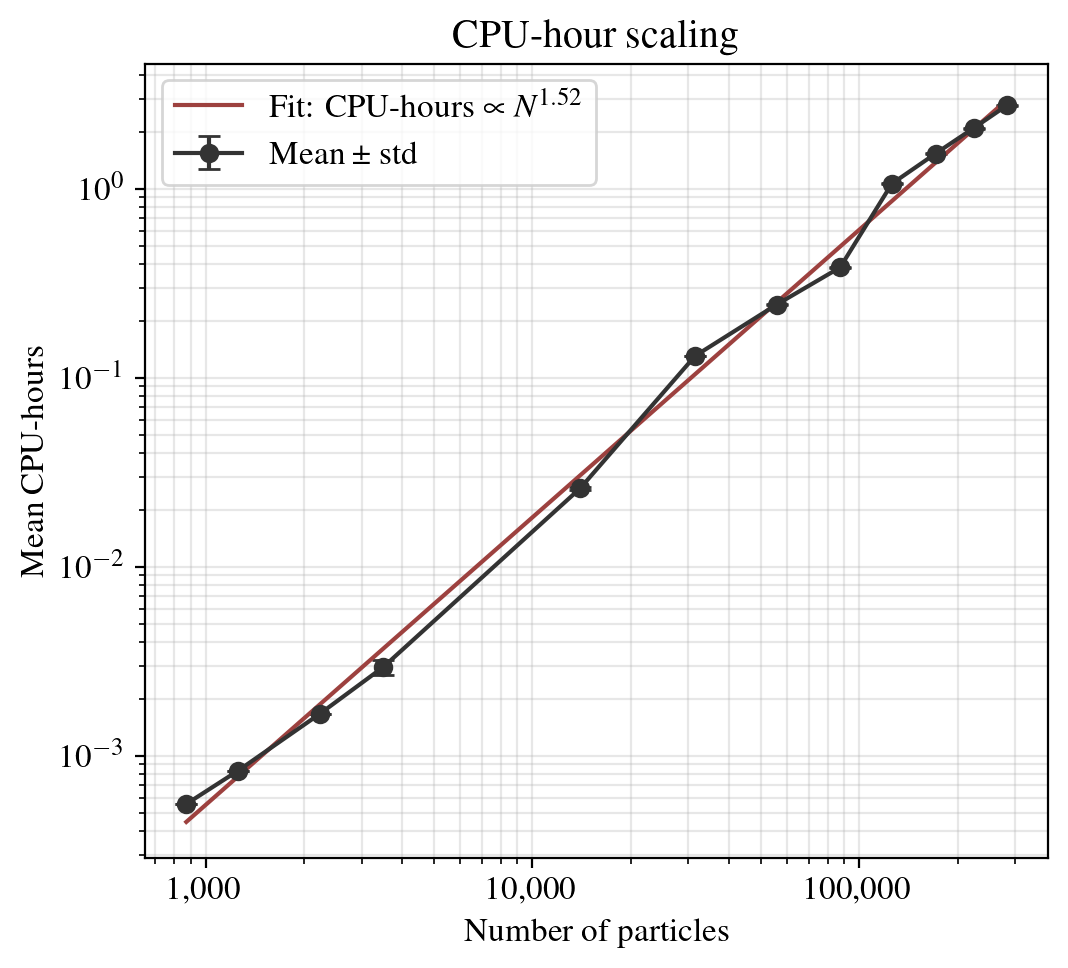

In [ ]:
json_path = "data/runs_dict.json"   

with open(json_path, "r") as f:
    runs_dict = json.load(f)

# JSON keys load as strings, so convert back to ints
runs_dict = {
    int(n_atoms): vals
    for n_atoms, vals in runs_dict.items()
}

# --- summarize by atom count ---
atom_counts = np.array(sorted(runs_dict.keys()), dtype=float)

mean_cpu_hours = np.array([
    np.mean(
        np.array(runs_dict[int(n)]["total_wall_time_s"], dtype=float)
        * np.array(runs_dict[int(n)]["n_cpus"], dtype=float)
        / 3600.0
    )
    for n in atom_counts
])

std_cpu_hours = np.array([
    np.std(
        np.array(runs_dict[int(n)]["total_wall_time_s"], dtype=float)
        * np.array(runs_dict[int(n)]["n_cpus"], dtype=float)
        / 3600.0
    )
    for n in atom_counts
])

n_runs = np.array([
    len(runs_dict[int(n)]["total_wall_time_s"])
    for n in atom_counts
], dtype=int)

# --- power-law fit: y = a * N^alpha ---
def fit_power_law(x, y):
    logx = np.log(x)
    logy = np.log(y)

    alpha, loga = np.polyfit(logx, logy, 1)
    a = np.exp(loga)

    y_fit = a * x**alpha

    # R^2 in log-log space
    ss_res = np.sum((logy - np.log(y_fit))**2)
    ss_tot = np.sum((logy - np.mean(logy))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return a, alpha, y_fit, r2

a_cpu, alpha_cpu, cpu_fit, r2_cpu = fit_power_law(atom_counts, mean_cpu_hours)

# --- print summary ---
print("CPU-hour performance summary:")
for n, nr, cpuh in zip(atom_counts.astype(int), n_runs, mean_cpu_hours):
    print(f"{n:>8} atoms | {nr:>3} runs | mean CPU-hours = {cpuh:.4f}")

print("\nPower-law fit:")
print(
    f"CPU-hours: c(N) = {a_cpu:.3e} * N^{alpha_cpu:.3f} "
    f"(R^2 in log-log space = {r2_cpu:.4f})"
)

# --- plot CPU-hour scaling ---
plt.figure(figsize=(5.5, 5))

plt.errorbar(
    atom_counts,
    mean_cpu_hours,
    yerr=std_cpu_hours,
    marker="o",
    capsize=4,
    color = "0.2",
    label="Mean ± std",
)

plt.plot(
    atom_counts,
    cpu_fit,
    label=fr"Fit: CPU-hours $\propto N^{{{alpha_cpu:.2f}}}$",
    color = '#9d413f',
)


plt.xscale("log")
plt.yscale("log")

plt.xticks([1000, 10000, 100000], ['1,000', '10,000', '100,000'])


plt.xlabel("Number of particles")
plt.ylabel("Mean CPU-hours")
plt.title("CPU-hour scaling")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_directory, 'compute_time.png'), dpi=300, bbox_inches='tight')
plt.show()